In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
 
loan_df = pd.read_csv(r"Loan_Default.csv")
 
loan_df.head()
 

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [3]:
loan_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  str    
 3   Gender                     148670 non-null  str    
 4   approv_in_adv              147762 non-null  str    
 5   loan_type                  148670 non-null  str    
 6   loan_purpose               148536 non-null  str    
 7   Credit_Worthiness          148670 non-null  str    
 8   open_credit                148670 non-null  str    
 9   business_or_commercial     148670 non-null  str    
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            109028 non-nu

In [4]:
loan_df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,148670.0,99224.500000,42917.476598,24890.000000,62057.25000,99224.50000,136391.750000,1.735590e+05
year,148670.0,2019.000000,0.000000,2019.000000,2019.00000,2019.00000,2019.000000,2.019000e+03
loan_amount,148670.0,331117.743997,183909.310127,16500.000000,196500.00000,296500.00000,436500.000000,3.576500e+06
rate_of_interest,112231.0,4.045476,0.561391,0.000000,3.62500,3.99000,4.375000,8.000000e+00
Interest_rate_spread,112031.0,0.441656,0.513043,-3.638000,0.07600,0.39040,0.775400,3.357000e+00
Upfront_charges,109028.0,3224.996127,3251.121510,0.000000,581.49000,2596.45000,4812.500000,6.000000e+04
term,148629.0,335.136582,58.409084,96.000000,360.00000,360.00000,360.000000,3.600000e+02
property_value,133572.0,497893.465696,359935.315562,8000.000000,268000.00000,418000.00000,628000.000000,1.650800e+07
income,139520.0,6957.338876,6496.586382,0.000000,3720.00000,5760.00000,8520.000000,5.785800e+05
Credit_Score,148670.0,699.789103,115.875857,500.000000,599.00000,699.00000,800.000000,9.000000e+02


In [5]:
loan_df.dtypes

ID                             int64
year                           int64
loan_limit                       str
Gender                           str
approv_in_adv                    str
loan_type                        str
loan_purpose                     str
Credit_Worthiness                str
open_credit                      str
business_or_commercial           str
loan_amount                    int64
rate_of_interest             float64
Interest_rate_spread         float64
Upfront_charges              float64
term                         float64
Neg_ammortization                str
interest_only                    str
lump_sum_payment                 str
property_value               float64
construction_type                str
occupancy_type                   str
Secured_by                       str
total_units                      str
income                       float64
credit_type                      str
Credit_Score                   int64
co-applicant_credit_type         str
a

In [6]:
loan_df["Status"].value_counts()

Status
0    112031
1     36639
Name: count, dtype: int64

<Axes: ylabel='Frequency'>

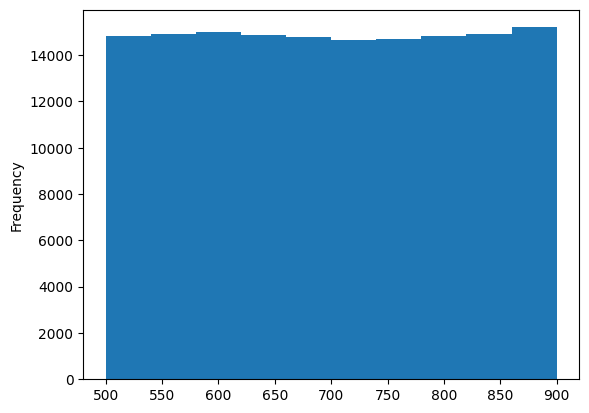

In [9]:
loan_df["Credit_Score"].plot.hist()

In [10]:
# numeric cutoff
loan_df["Fake_Target"] = np.where(loan_df["Credit_Score"] < 580, 1, 0)
 
loan_df["Fake_Target"].value_counts()

Fake_Target
0    118933
1     29737
Name: count, dtype: int64

In [11]:
loan_df["loan_type"].value_counts()

loan_type
type1    113173
type2     20762
type3     14735
Name: count, dtype: int64

In [12]:
loan_df.shape

(148670, 35)

In [13]:
# category mapping
 
loan_df["Fake_Target"] = (
    loan_df["loan_type"].map(
        {"type1": 0,
         "type2": 1,
         "type3": 1
        }
    )
)
 
loan_df["Fake_Target"].value_counts()

Fake_Target
0    113173
1     35497
Name: count, dtype: int64

<Axes: xlabel='Status'>

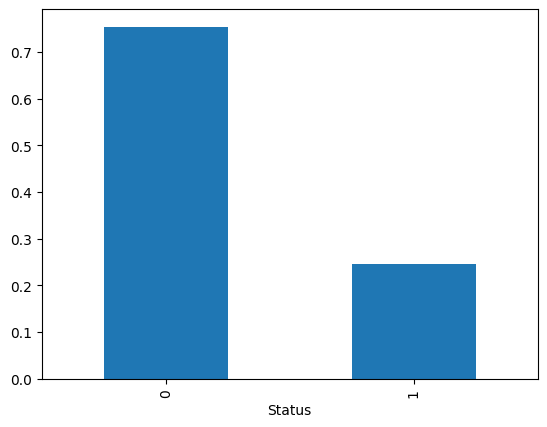

In [14]:
loan_df["Status"].value_counts(normalize=True).plot.bar()

In [15]:
loan_df = loan_df.drop("Fake_Target", axis=1)

<Axes: ylabel='Frequency'>

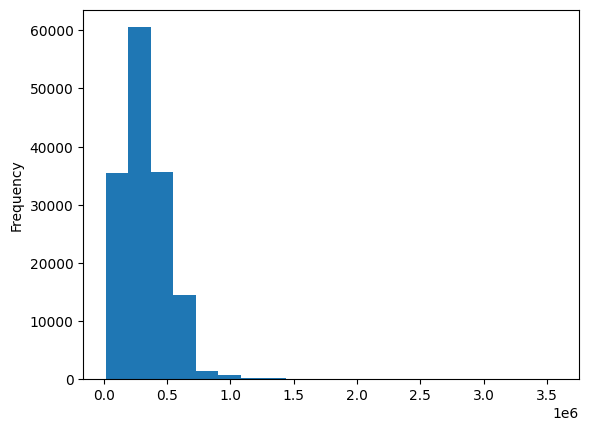

In [16]:
loan_df["loan_amount"].plot.hist(bins=20)

<Axes: ylabel='loan_amount'>

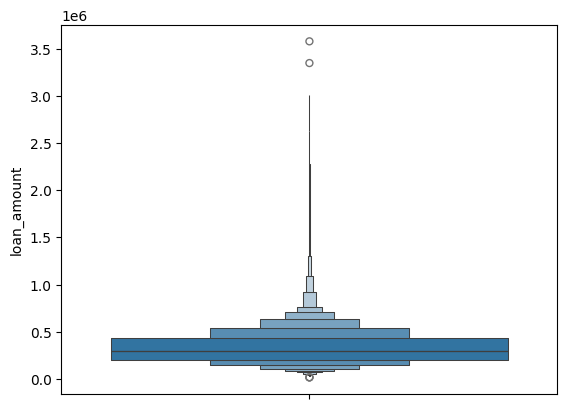

In [20]:
import seaborn as sns
 
sns.boxenplot(loan_df["loan_amount"])

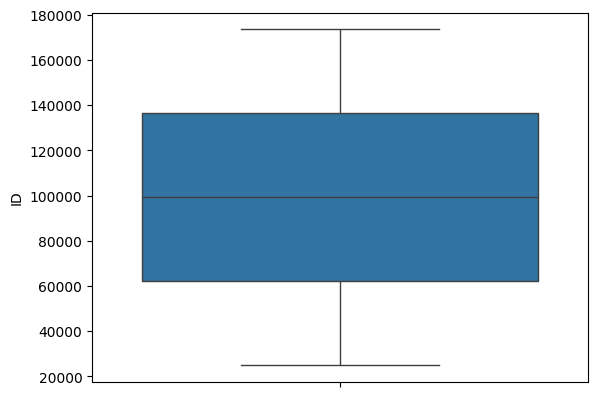

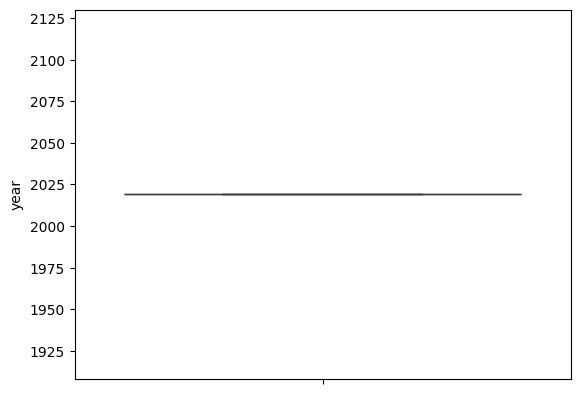

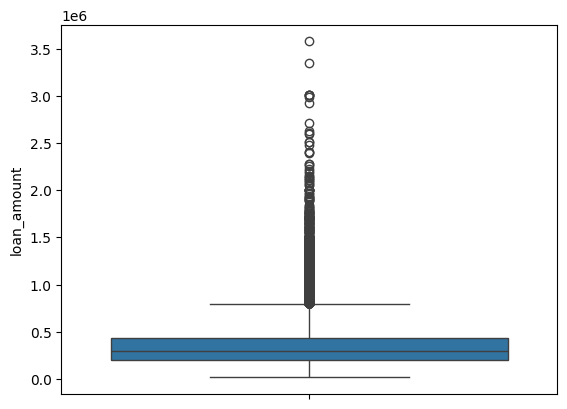

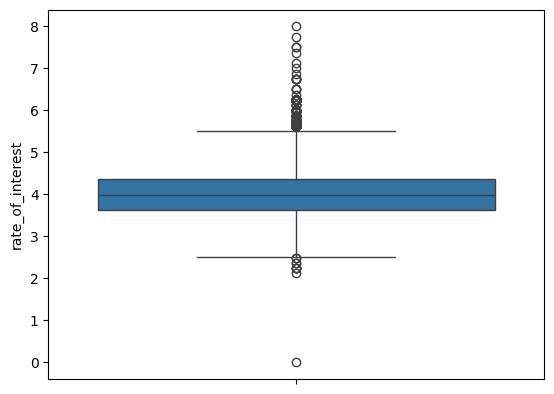

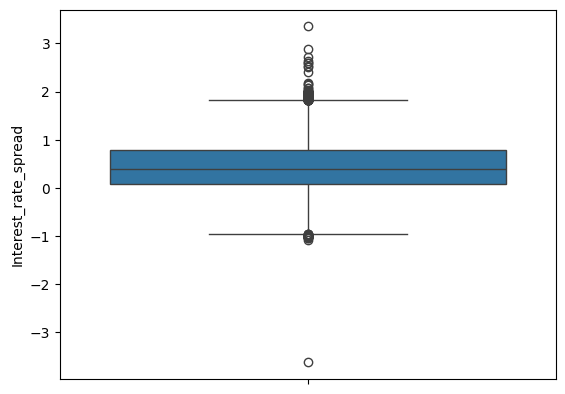

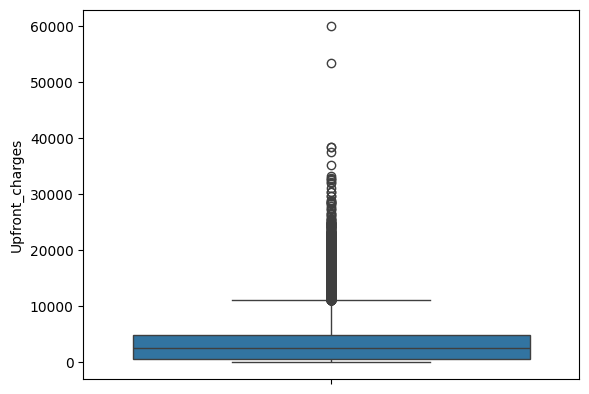

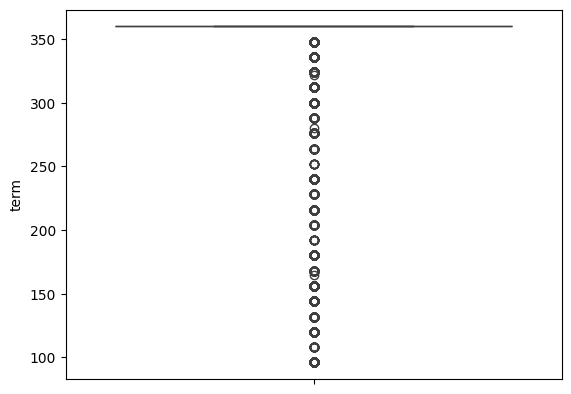

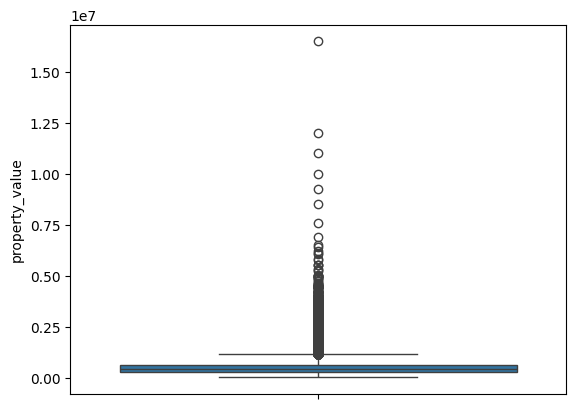

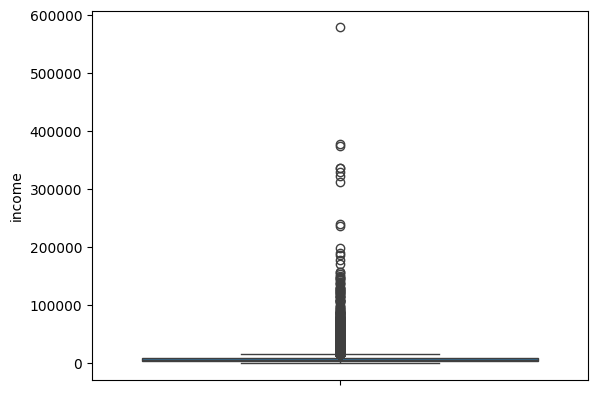

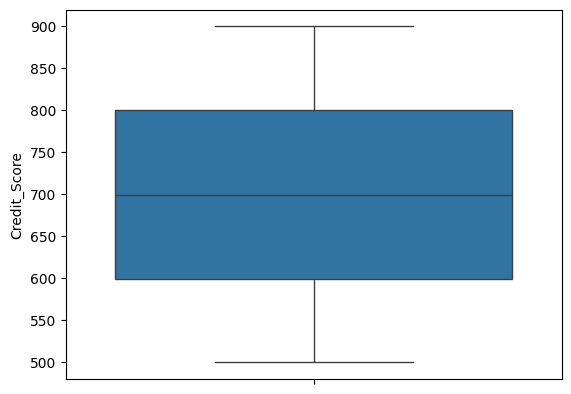

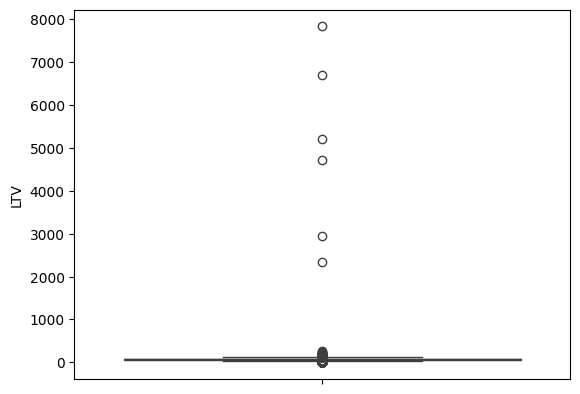

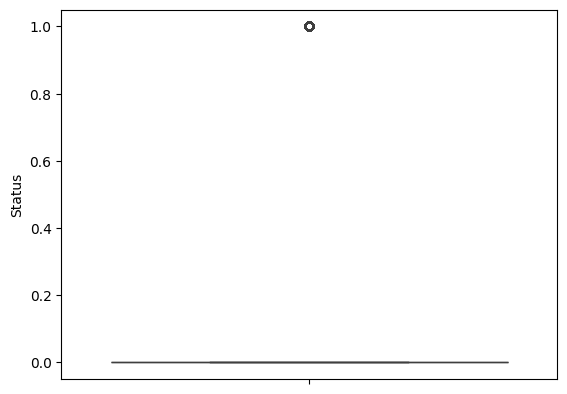

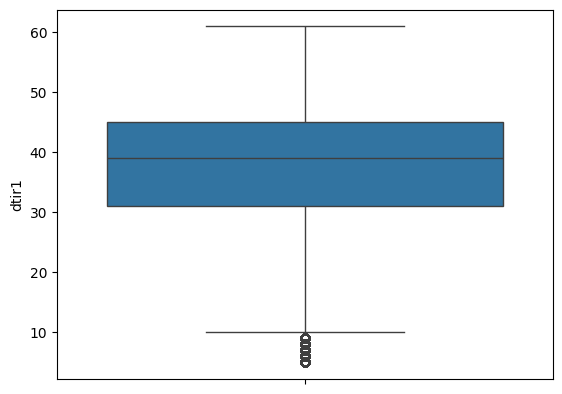

In [21]:
import matplotlib.pyplot as plt
 
# select numeric dtype columns and plot vs target
 
for column in loan_df.select_dtypes("number").columns:
    sns.boxplot(loan_df[column]).set(ylabel=column)
    plt.show()

<Axes: ylabel='Gender'>

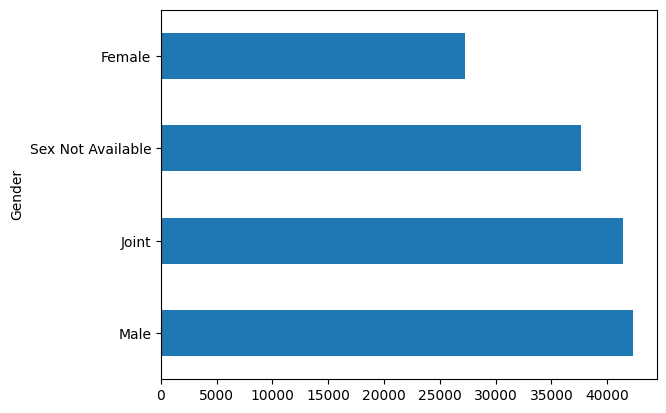

In [22]:
loan_df["Gender"].value_counts().plot.barh()

C:\Users\modis\AppData\Local\Temp\ipykernel_18768\4192512578.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in loan_df.select_dtypes("object").columns:


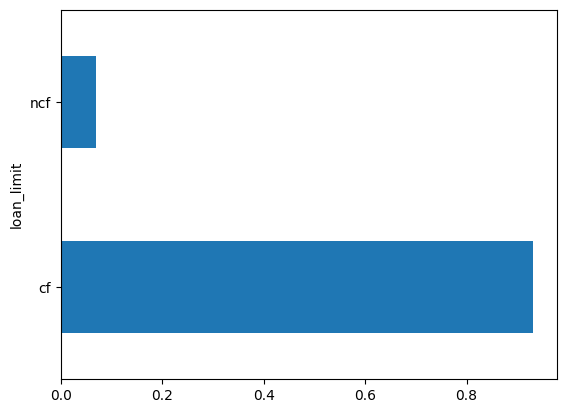

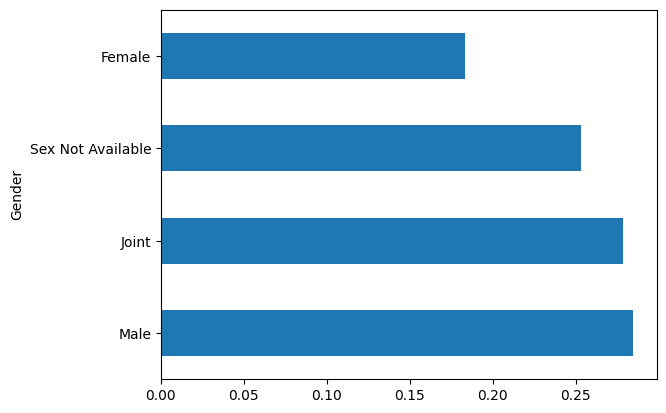

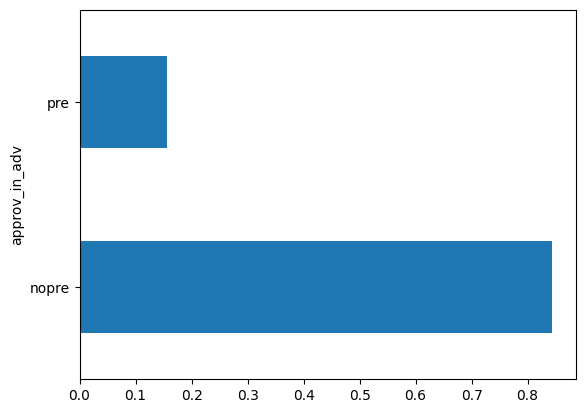

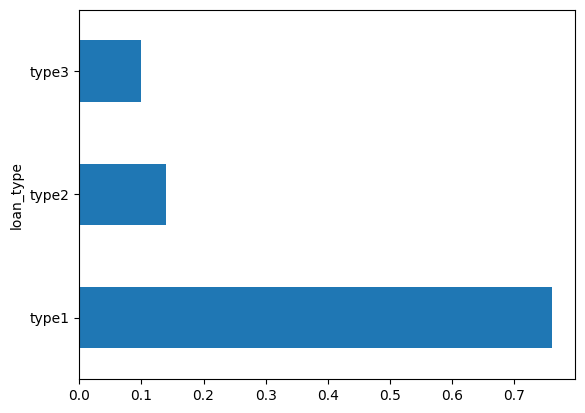

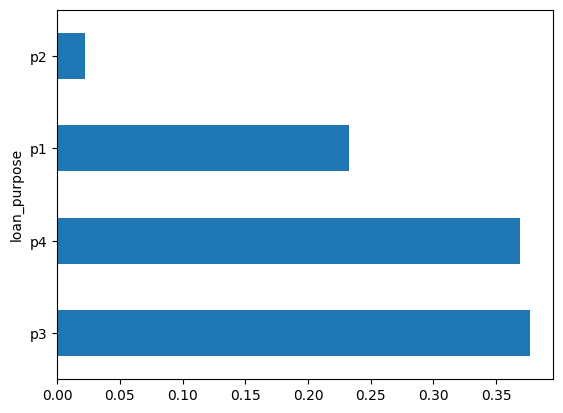

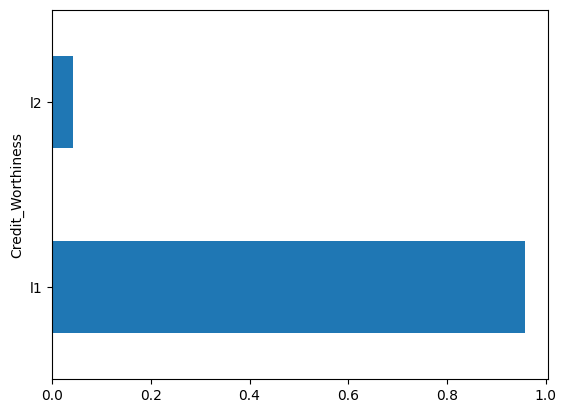

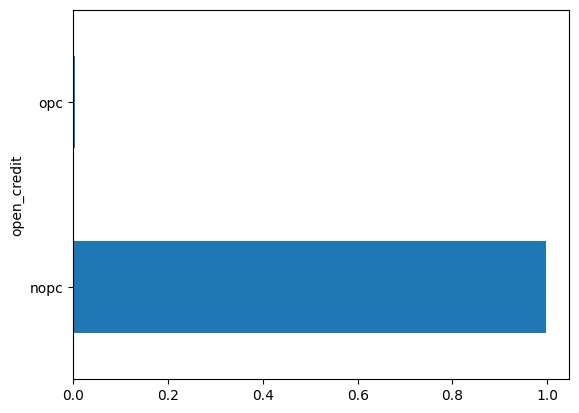

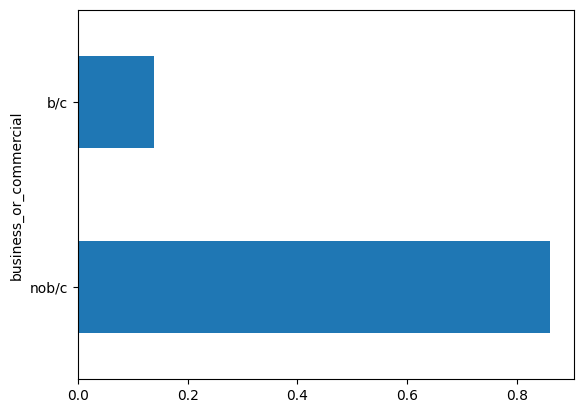

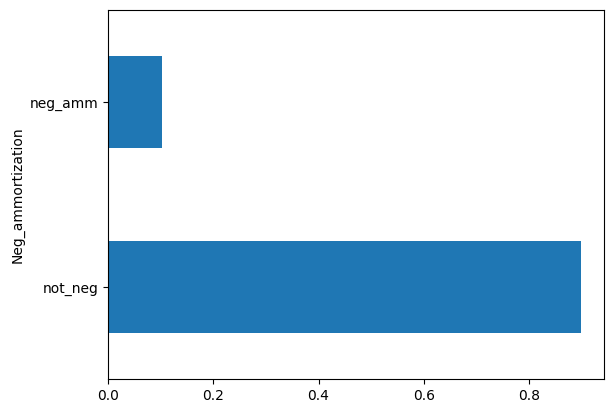

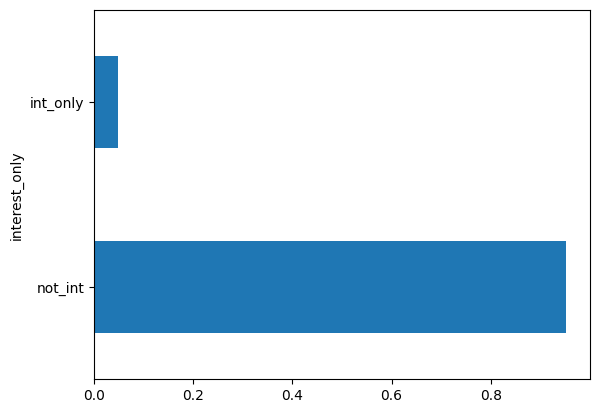

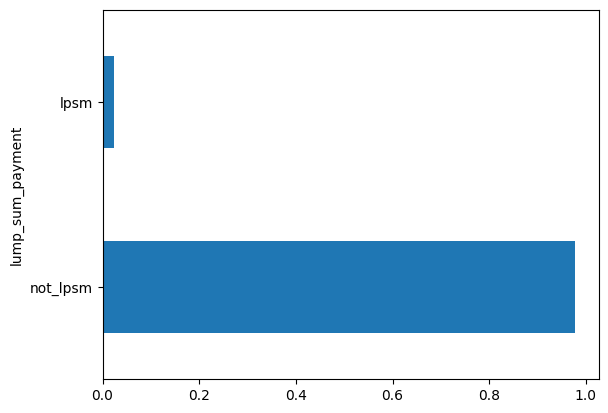

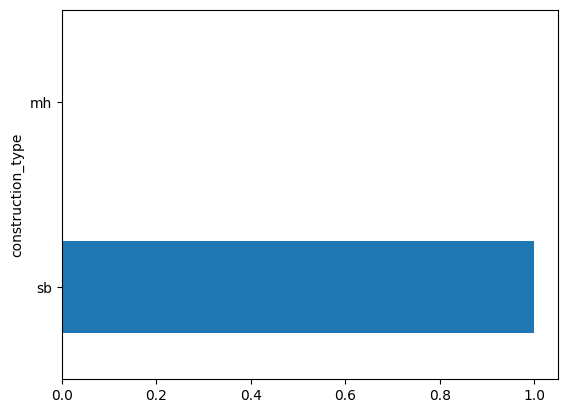

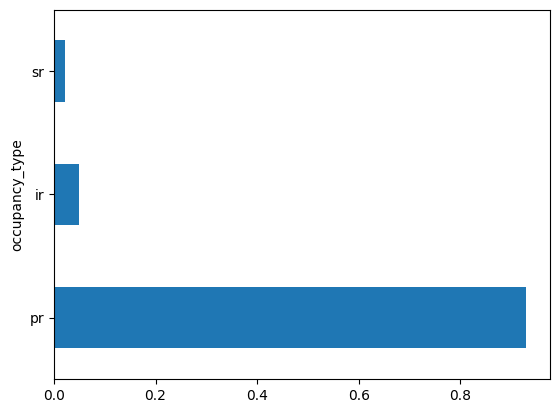

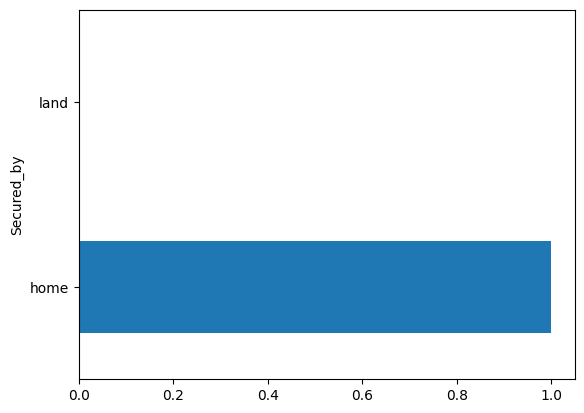

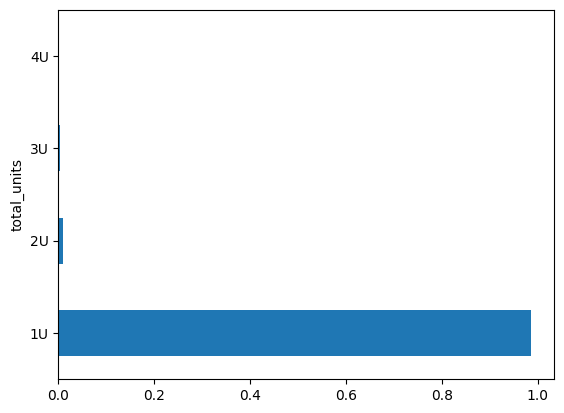

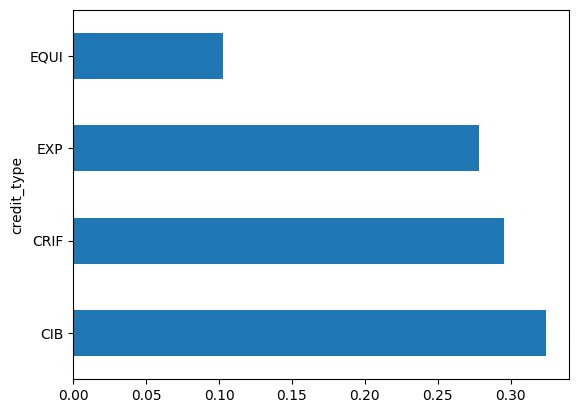

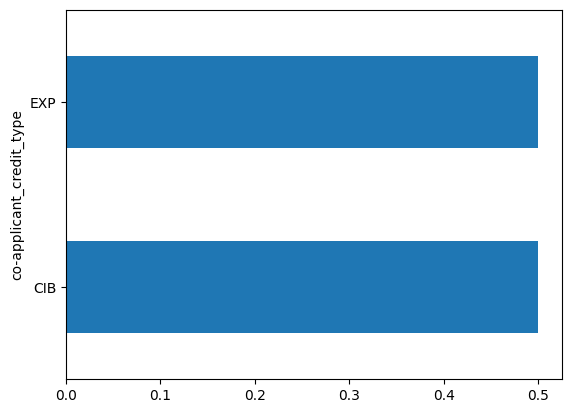

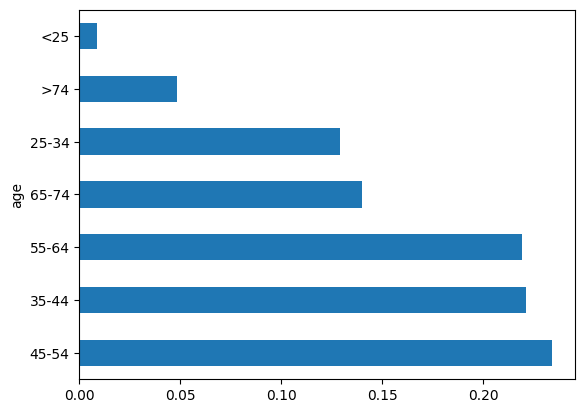

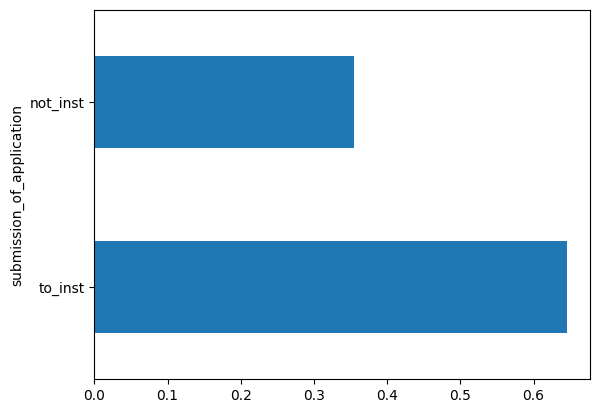

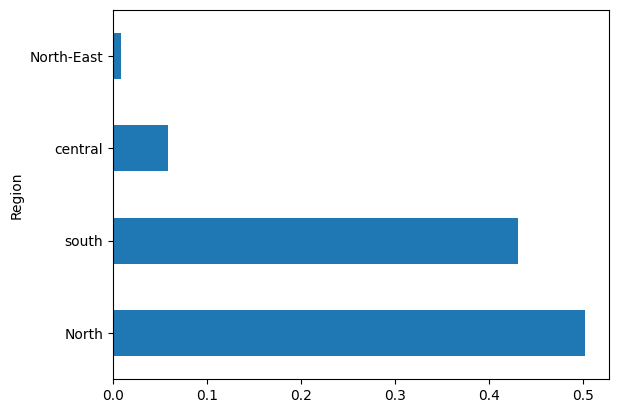

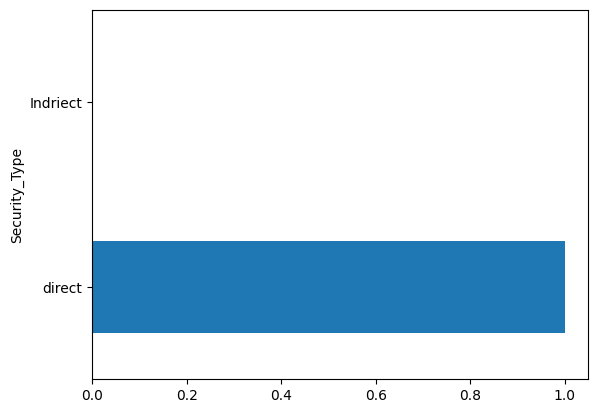

In [24]:
# select object dtype columns and plot vs target
 
for column in loan_df.select_dtypes("object").columns:
    loan_df[column].value_counts(normalize=True).plot.barh()
    plt.show()

<Axes: xlabel='loan_amount', ylabel='property_value'>

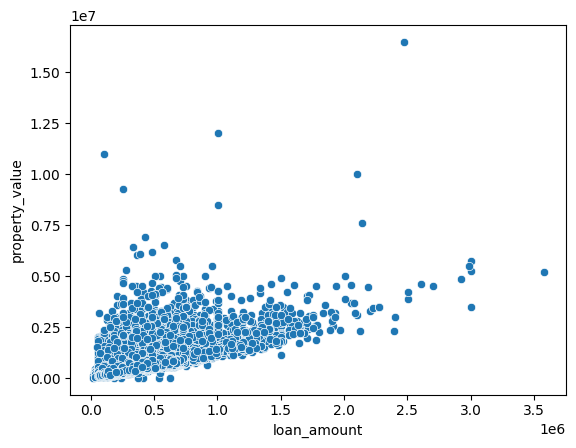

In [25]:
sns.scatterplot(loan_df, x="loan_amount", y="property_value")

In [26]:
loan_df["loan_amount"].corr(loan_df["property_value"])

np.float64(0.7342490169595312)

In [27]:
loan_df["loan_amount"].corr(loan_df["Status"])

np.float64(-0.036825275544374515)

In [28]:
loan_df.corr(numeric_only=True).round(2)

,ID,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
ID,1.00,NaN,-0.00,0.00,0.00,-0.01,-0.00,0.00,0.00,-0.00,-0.01,0.00,-0.01
year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amount,-0.00,NaN,1.00,-0.15,-0.38,0.07,0.17,0.73,0.46,0.00,0.04,-0.04,0.02
rate_of_interest,0.00,NaN,-0.15,1.00,0.61,-0.08,0.21,-0.12,-0.04,-0.00,-0.00,0.02,0.06
Interest_rate_spread,0.00,NaN,-0.38,0.61,1.00,0.03,-0.16,-0.33,-0.15,-0.00,0.04,NaN,0.08
Upfront_charges,-0.01,NaN,0.07,-0.08,0.03,1.00,-0.05,0.05,0.02,-0.00,-0.03,-0.02,0.00
term,-0.00,NaN,0.17,0.21,-0.16,-0.05,1.00,0.05,-0.05,-0.00,0.11,-0.00,0.11
property_value,0.00,NaN,0.73,-0.12,-0.33,0.05,0.05,1.00,0.41,0.00,-0.22,-0.05,-0.06
income,0.00,NaN,0.46,-0.04,-0.15,0.02,-0.05,0.41,1.00,0.00,-0.07,-0.07,-0.27
Credit_Score,-0.00,NaN,0.00,-0.00,-0.00,-0.00,-0.00,0.00,0.00,1.00,-0.01,0.00,-0.00


<Axes: >

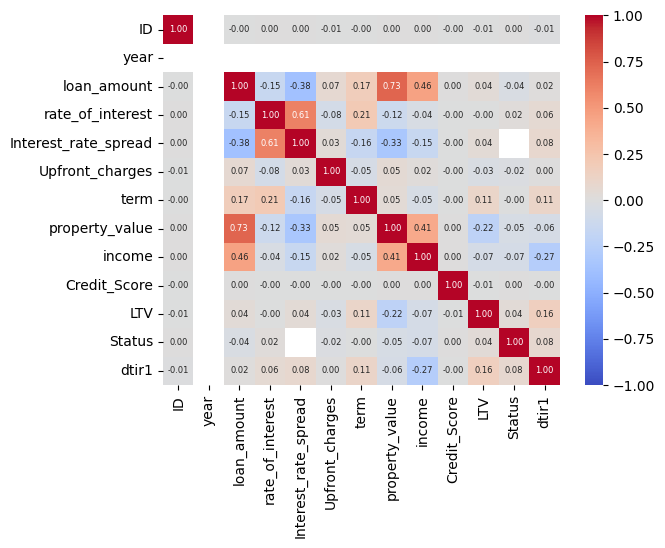

In [29]:
sns.heatmap(
    loan_df.corr(numeric_only=True),
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    annot_kws={"size":6}
)

<Axes: xlabel='Status', ylabel='loan_amount'>

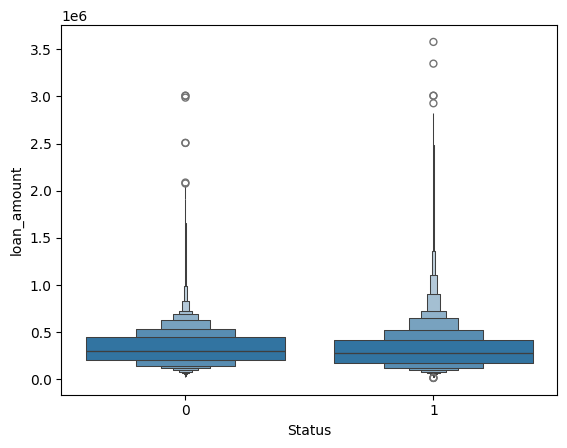

In [30]:
sns.boxenplot(loan_df, x="Status", y="loan_amount")

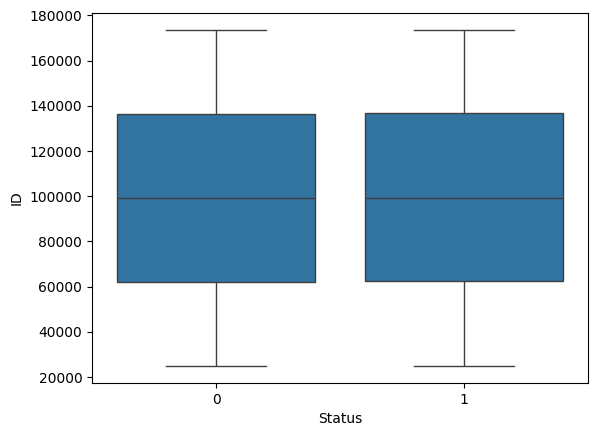

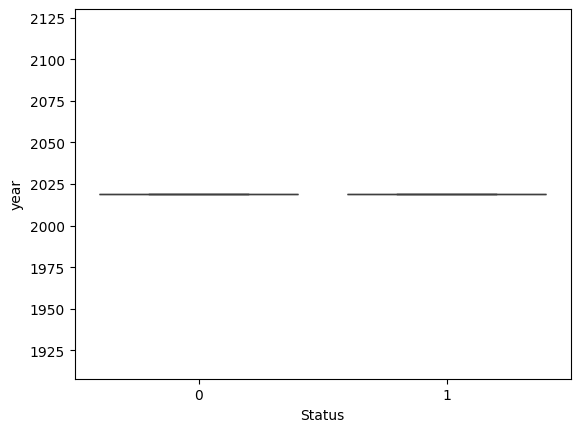

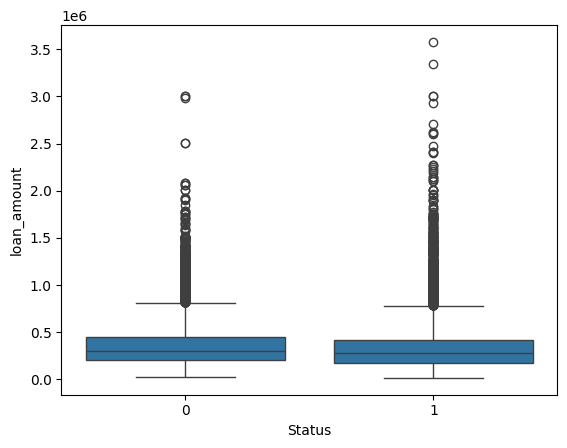

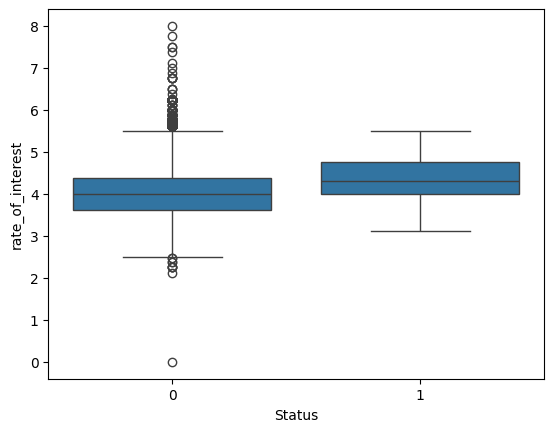

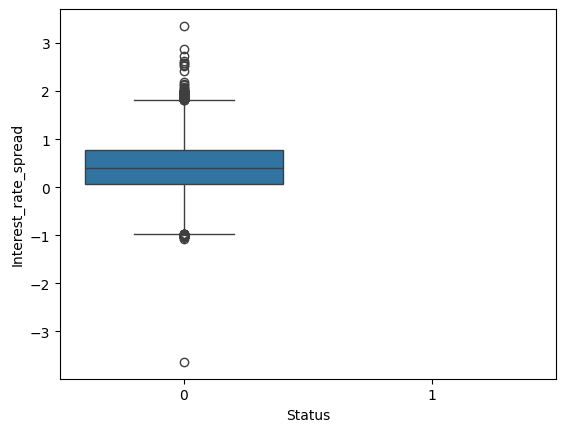

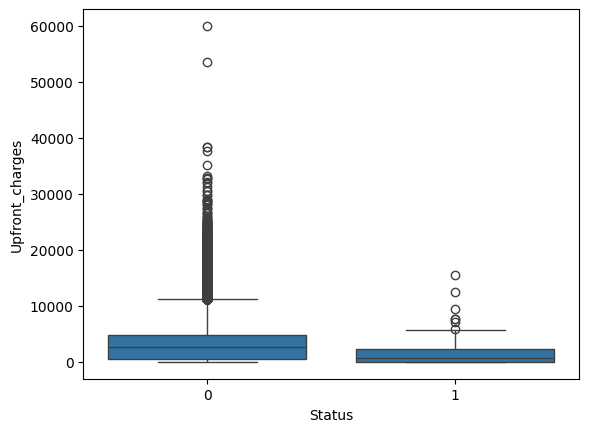

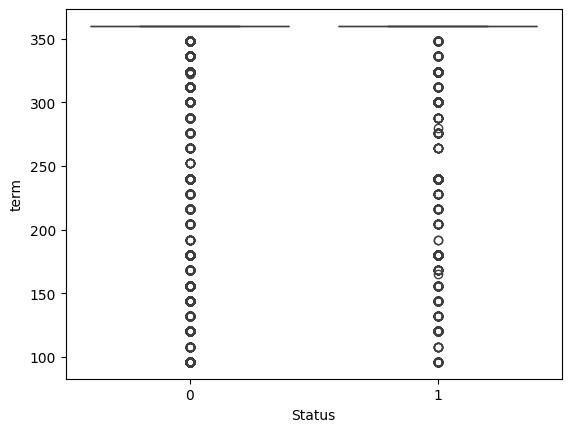

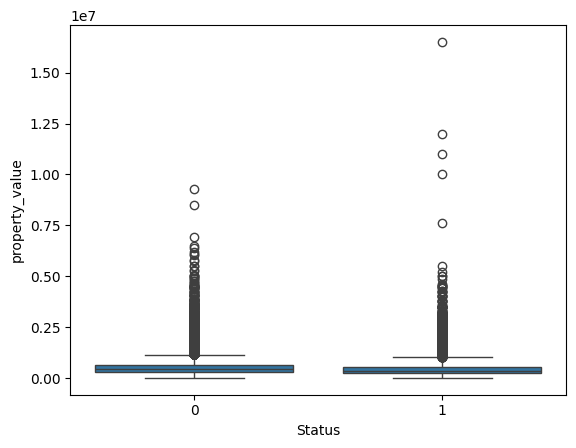

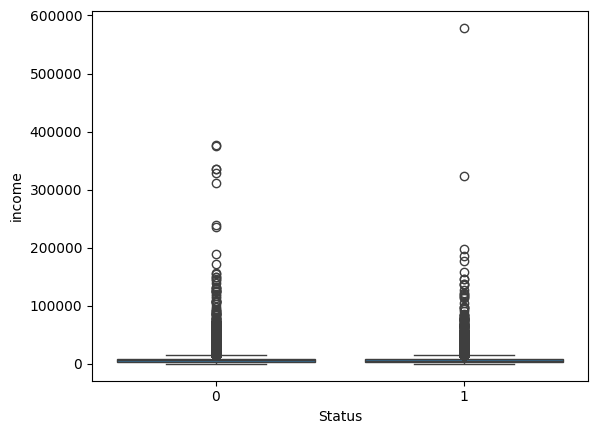

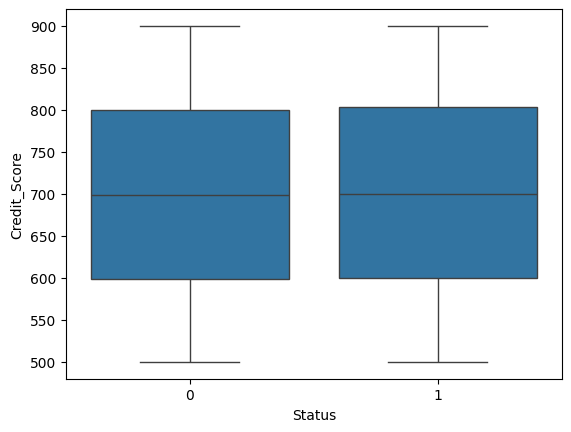

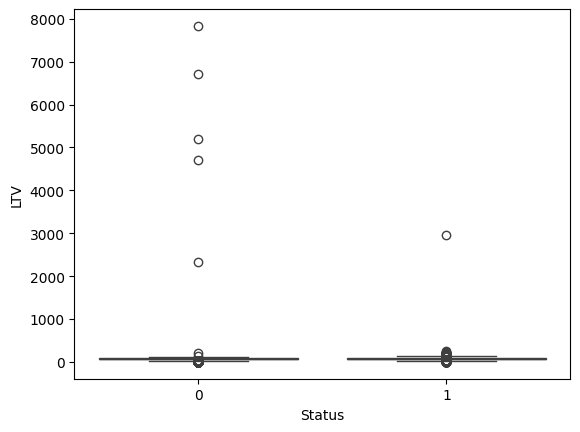

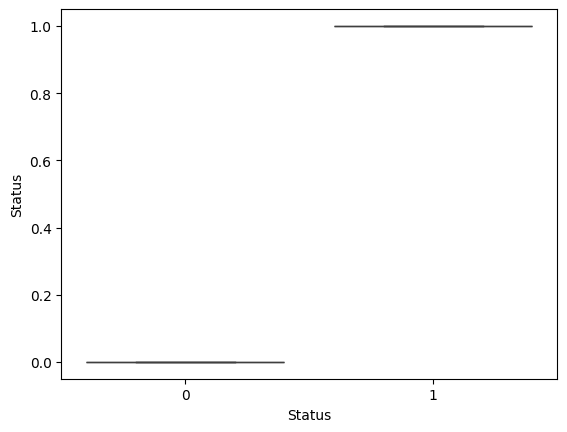

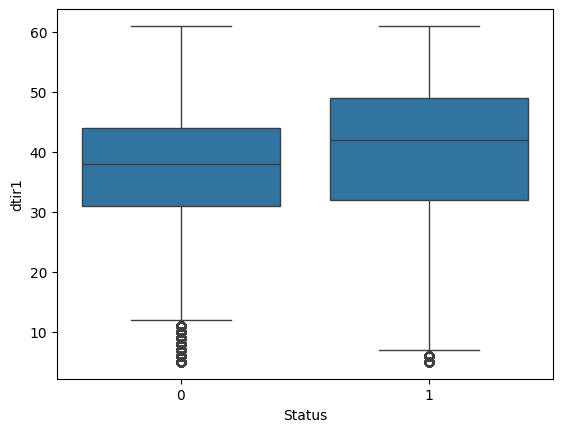

In [31]:
def box_target_plotter(data, target):
    for col in data.select_dtypes("number"):
        sns.boxplot(data=data, x=target, y=col)
        plt.show()
       
box_target_plotter(loan_df, "Status")

<Axes: xlabel='loan_amount', ylabel='Percent'>

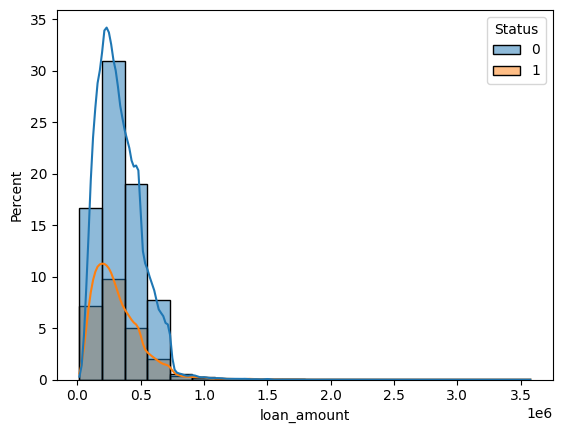

In [32]:
sns.histplot(loan_df, x="loan_amount", hue="Status", stat="percent", kde=True, bins=20)

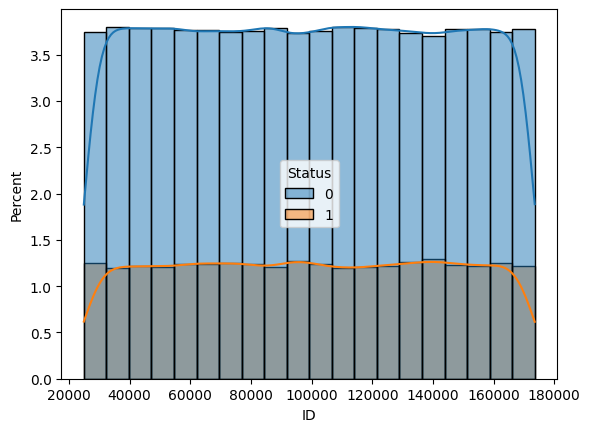

LinAlgError: The data appears to lie in a lower-dimensional subspace of the space in which it is expressed. This has resulted in a singular data covariance matrix, which cannot be treated using the algorithms implemented in `gaussian_kde`. Consider performing principal component analysis / dimensionality reduction and using `gaussian_kde` with the transformed data.

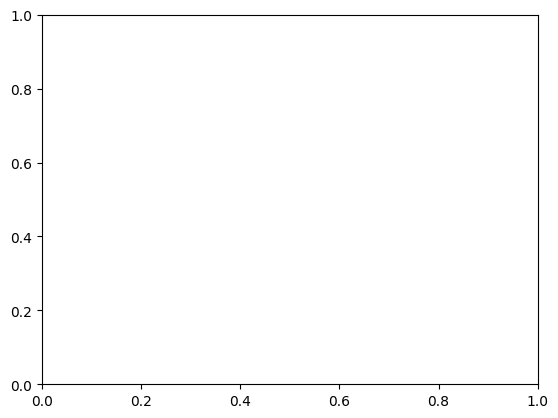

In [33]:
def hist_target_plotter(data, target):
    for col in data.select_dtypes("number"):
        sns.histplot(data=data, x=col, hue=target, stat="percent", kde=True, bins=20
                   )
        plt.show()
       
hist_target_plotter(loan_df, "Status")

C:\Users\modis\AppData\Local\Temp\ipykernel_18768\4088850612.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in data.select_dtypes(["object"]).columns:
C:\Users\modis\AppData\Local\Temp\ipykernel_18768\4088850612.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


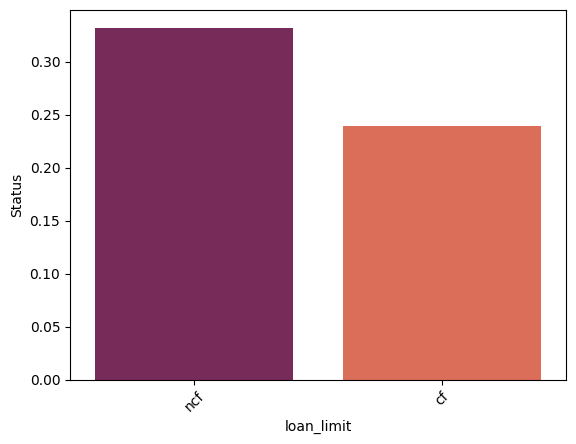

C:\Users\modis\AppData\Local\Temp\ipykernel_18768\4088850612.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


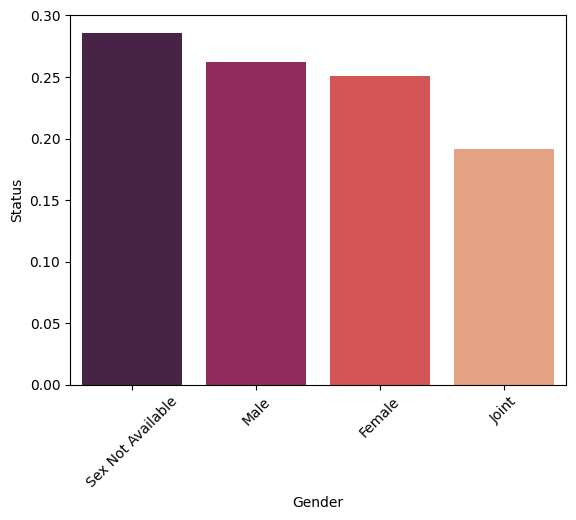

C:\Users\modis\AppData\Local\Temp\ipykernel_18768\4088850612.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


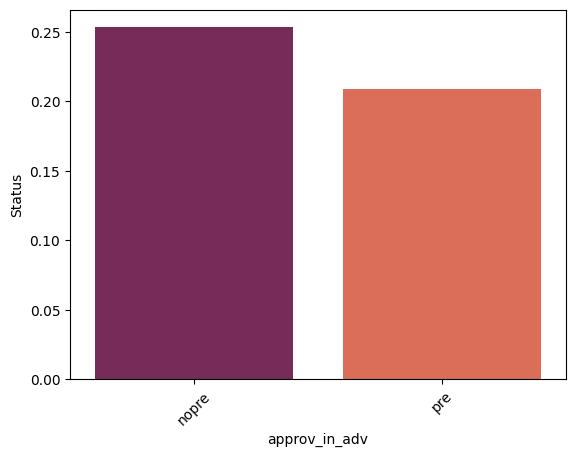

C:\Users\modis\AppData\Local\Temp\ipykernel_18768\4088850612.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


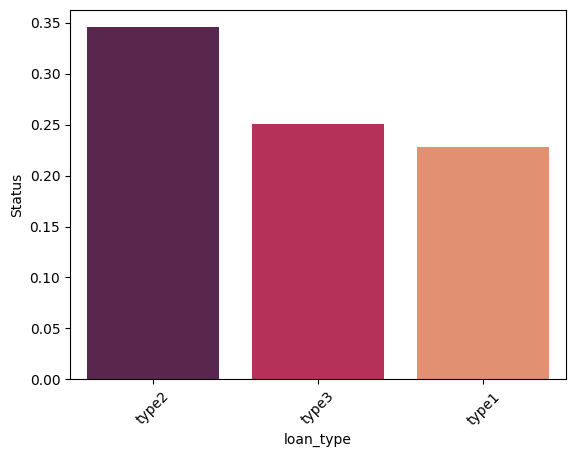

C:\Users\modis\AppData\Local\Temp\ipykernel_18768\4088850612.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


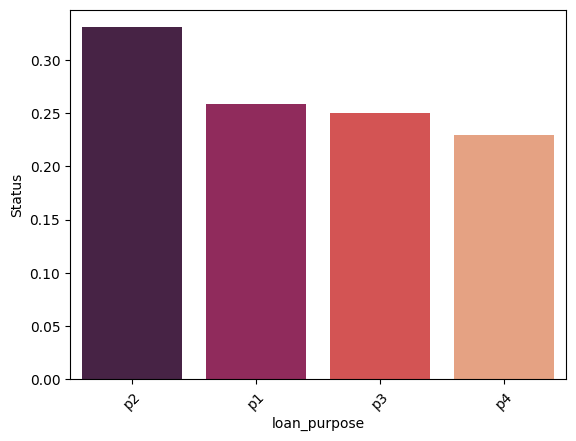

C:\Users\modis\AppData\Local\Temp\ipykernel_18768\4088850612.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


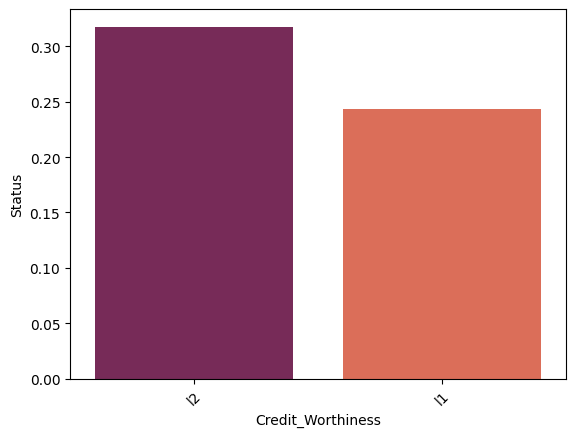

C:\Users\modis\AppData\Local\Temp\ipykernel_18768\4088850612.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


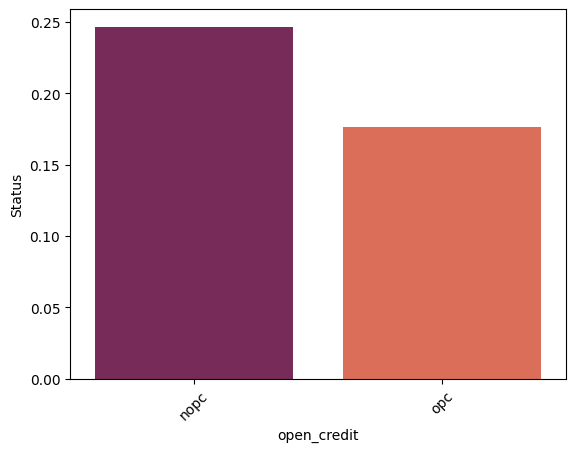

C:\Users\modis\AppData\Local\Temp\ipykernel_18768\4088850612.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


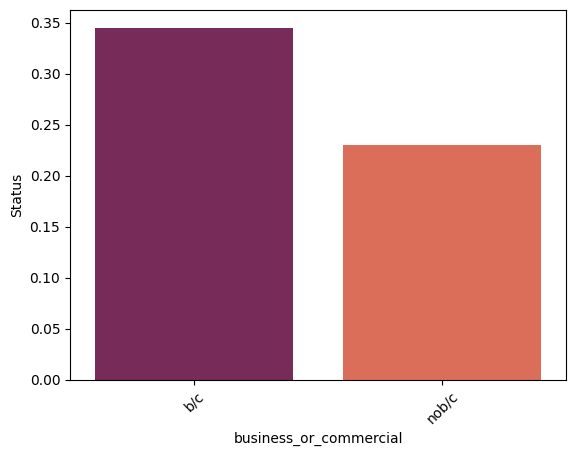

C:\Users\modis\AppData\Local\Temp\ipykernel_18768\4088850612.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


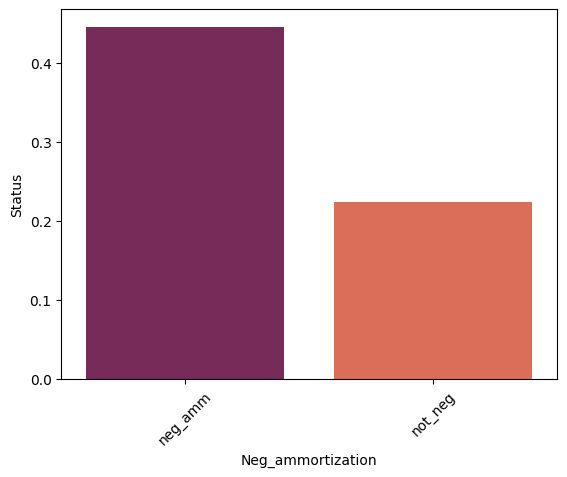

C:\Users\modis\AppData\Local\Temp\ipykernel_18768\4088850612.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


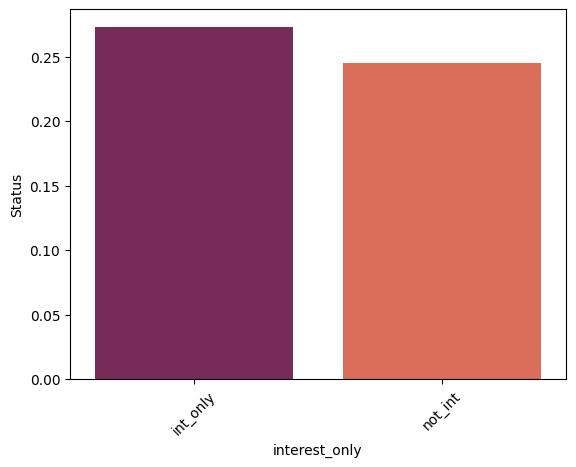

C:\Users\modis\AppData\Local\Temp\ipykernel_18768\4088850612.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


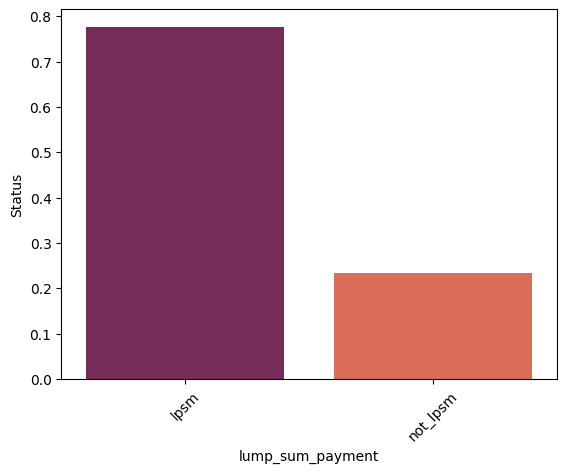

C:\Users\modis\AppData\Local\Temp\ipykernel_18768\4088850612.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


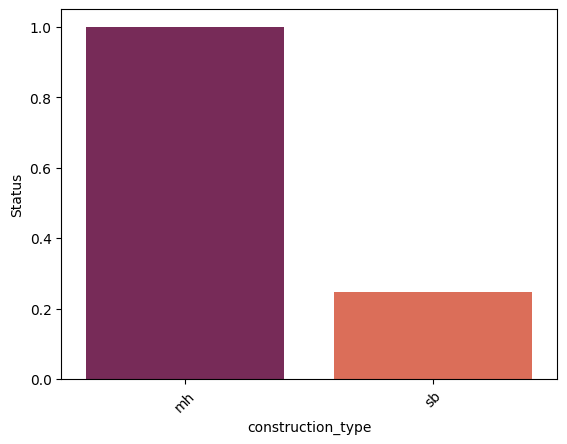

C:\Users\modis\AppData\Local\Temp\ipykernel_18768\4088850612.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


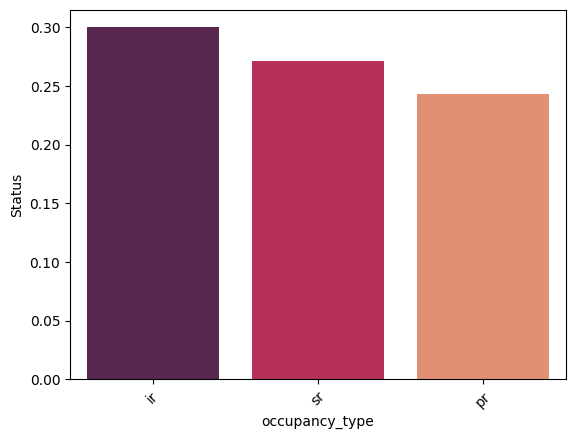

C:\Users\modis\AppData\Local\Temp\ipykernel_18768\4088850612.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


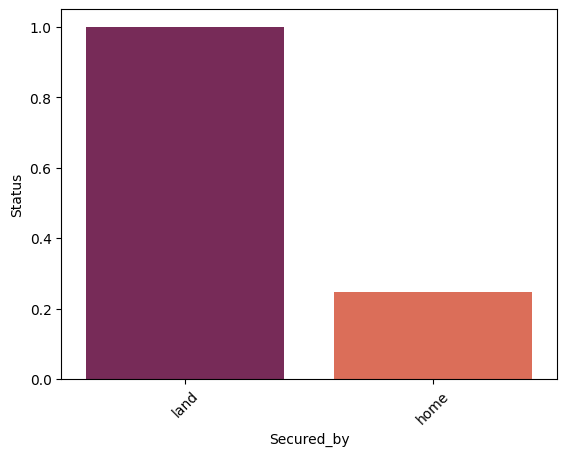

C:\Users\modis\AppData\Local\Temp\ipykernel_18768\4088850612.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


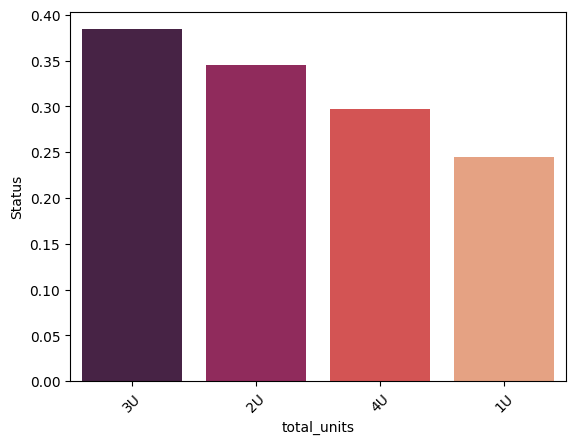

C:\Users\modis\AppData\Local\Temp\ipykernel_18768\4088850612.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


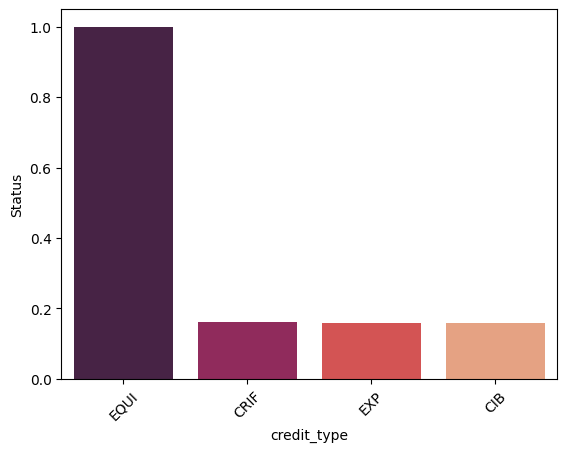

C:\Users\modis\AppData\Local\Temp\ipykernel_18768\4088850612.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


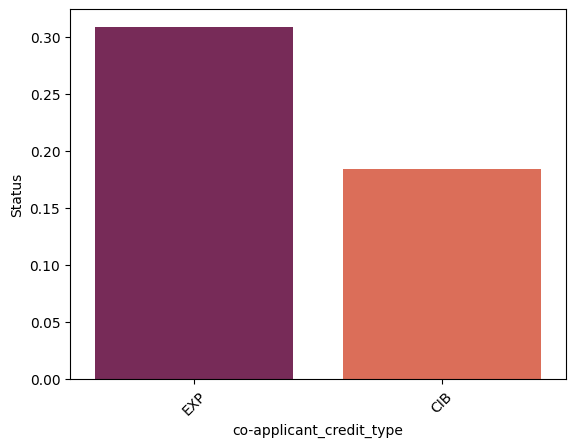

C:\Users\modis\AppData\Local\Temp\ipykernel_18768\4088850612.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


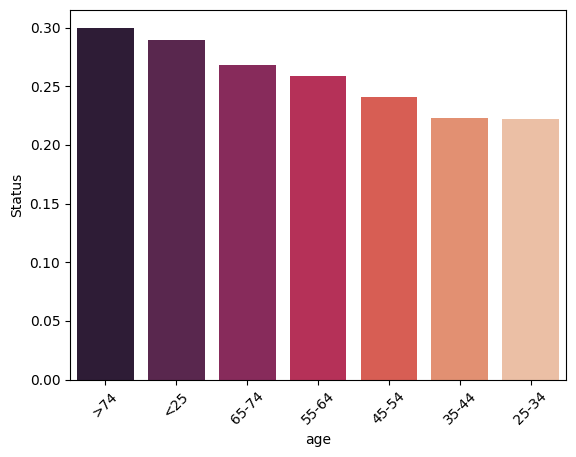

C:\Users\modis\AppData\Local\Temp\ipykernel_18768\4088850612.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


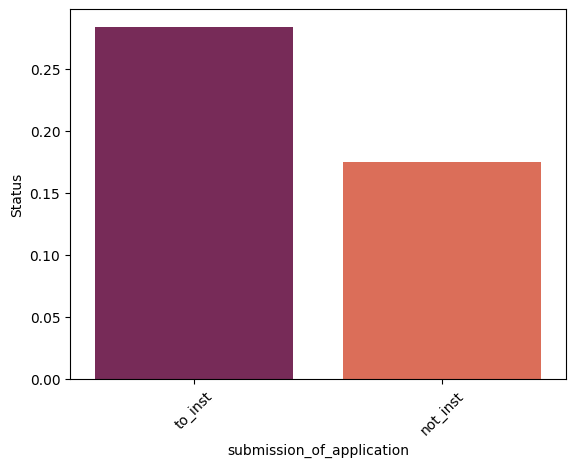

C:\Users\modis\AppData\Local\Temp\ipykernel_18768\4088850612.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


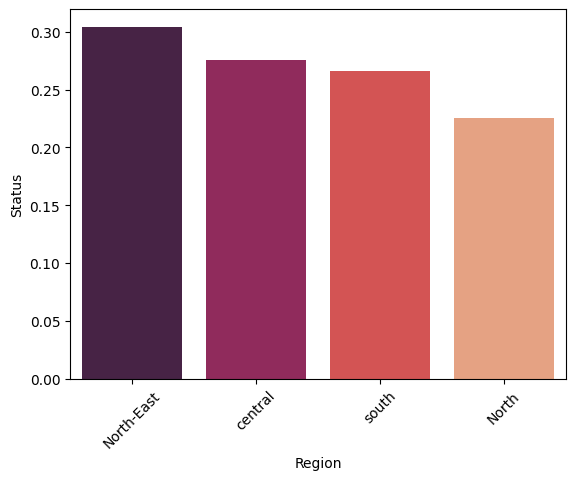

C:\Users\modis\AppData\Local\Temp\ipykernel_18768\4088850612.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


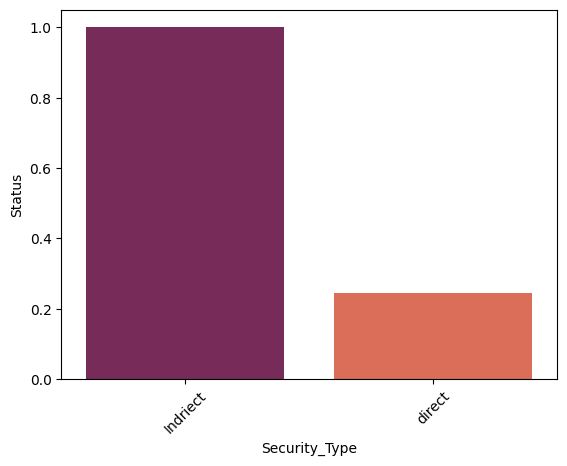

In [40]:
def cat_plotter(data, target):
    for col in data.select_dtypes(["object"]).columns:
        sns.barplot(
            data=(
                data
                .groupby(col, as_index=False)
                .agg({target: "mean"})
                .sort_values(by=target, ascending=False)
                 ),
            x=col,
            y=target,
            palette="rocket")
        plt.xticks(rotation=45)
        plt.show()
       
cat_plotter(loan_df, "Status")

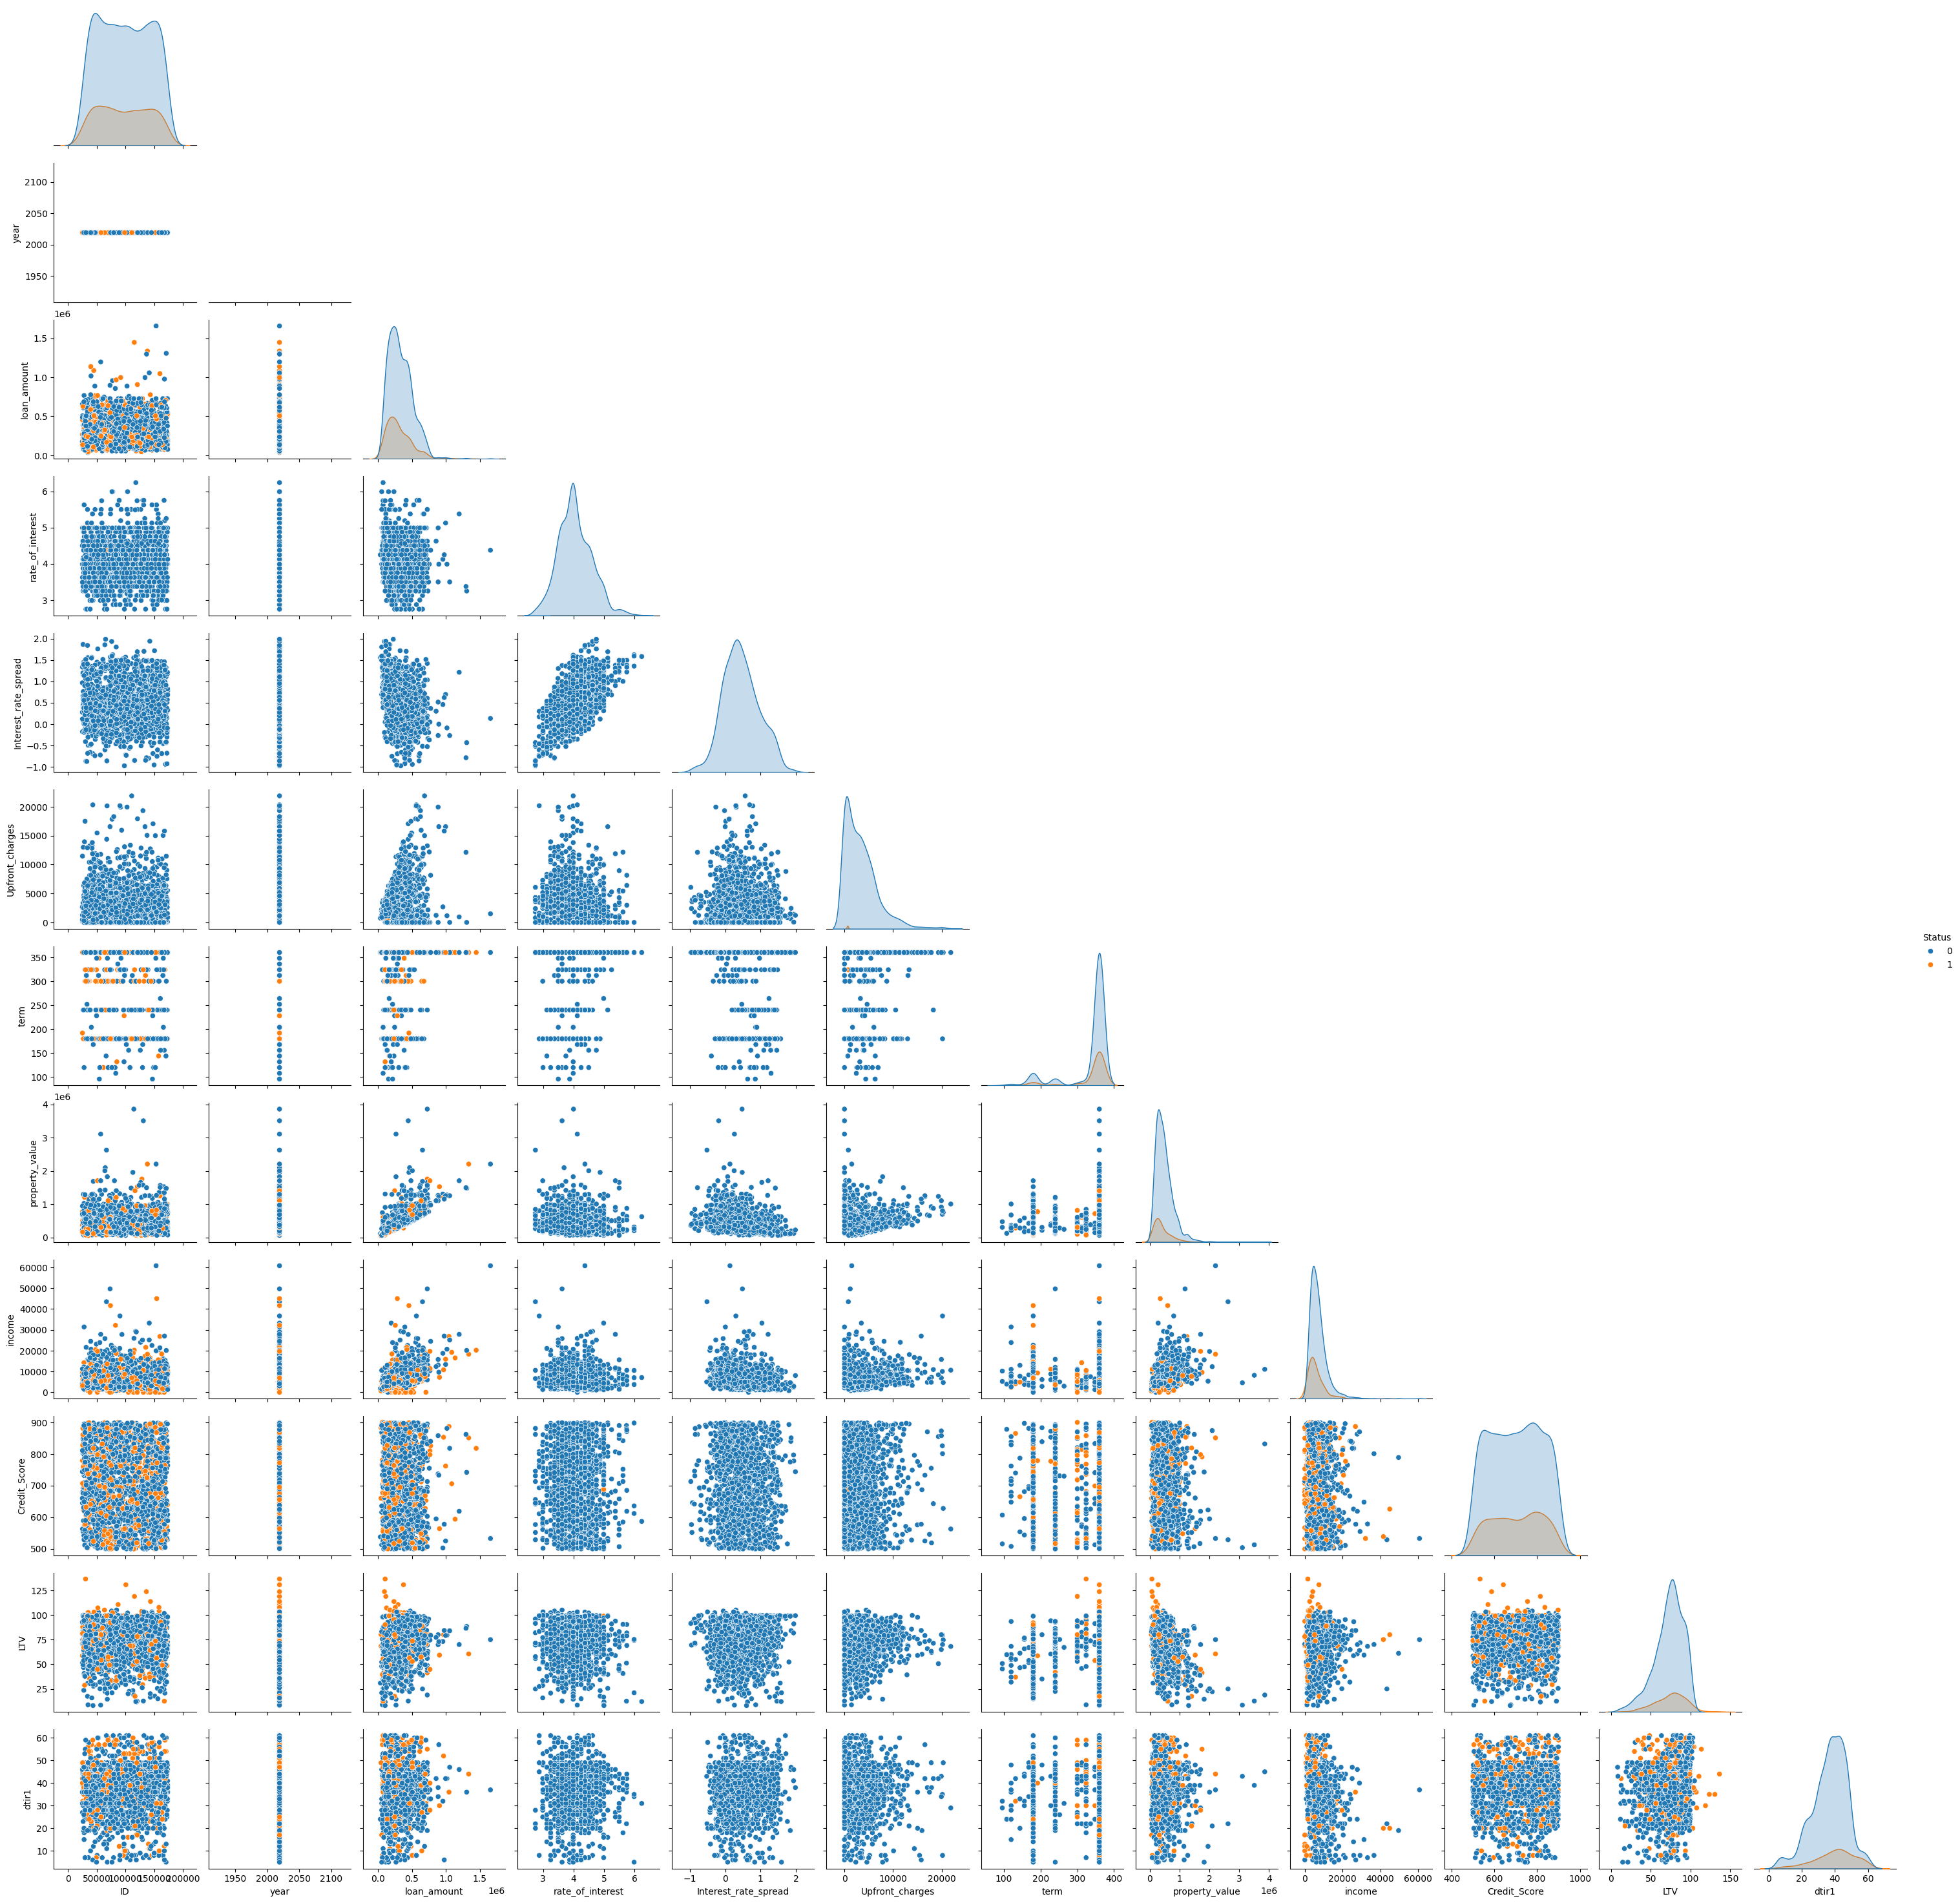

In [41]:
sns.pairplot(loan_df.sample(2000), hue="Status", corner=True)

<Axes: xlabel='loan_amount', ylabel='income'>

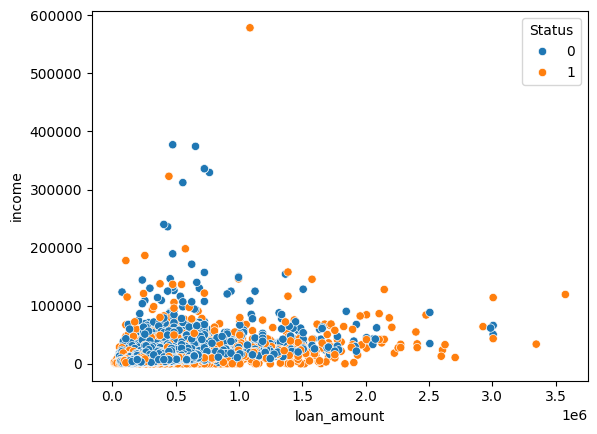

In [42]:
sns.scatterplot(loan_df, x="loan_amount", y="income", hue="Status" )

C:\Users\modis\AppData\Local\Temp\ipykernel_18768\3980741272.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in loan_df.select_dtypes("object").columns:


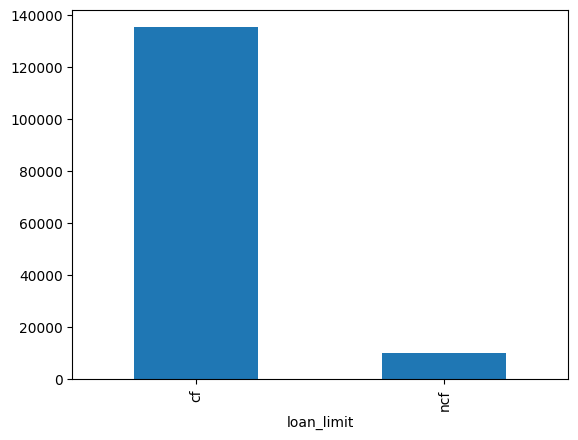

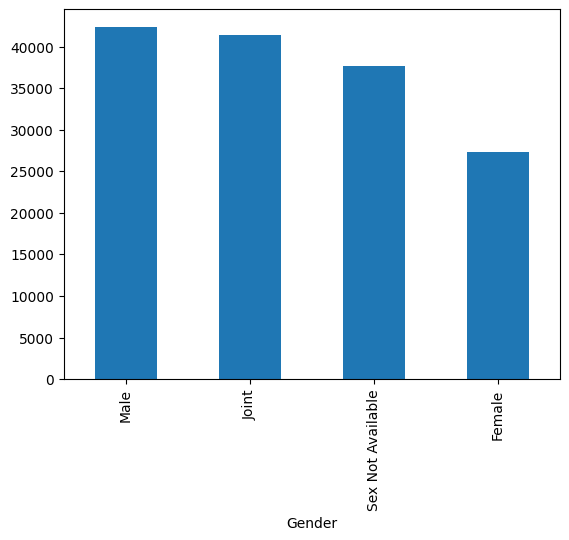

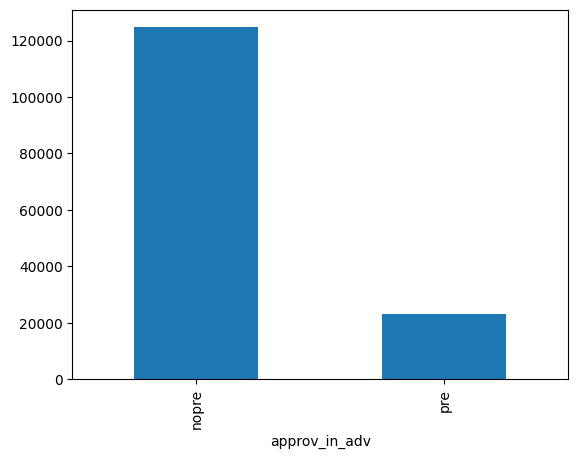

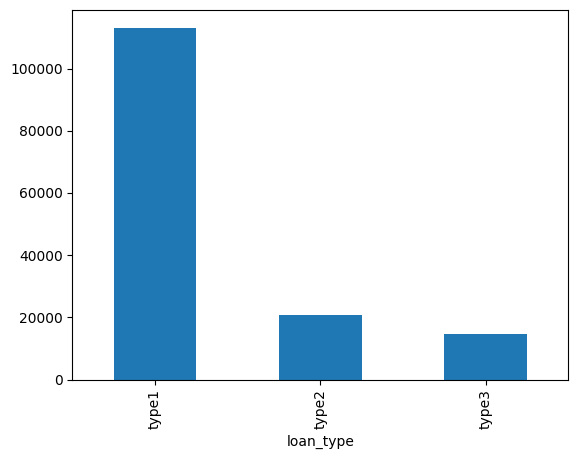

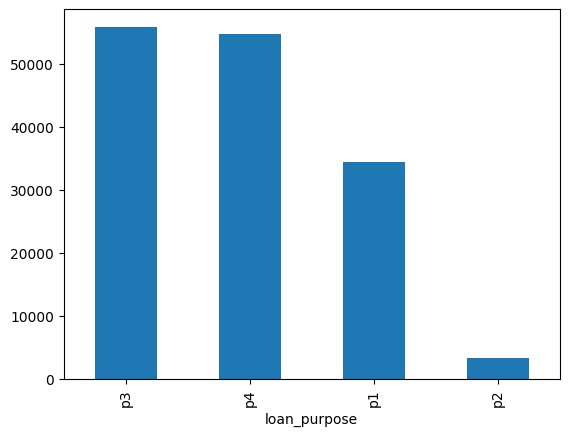

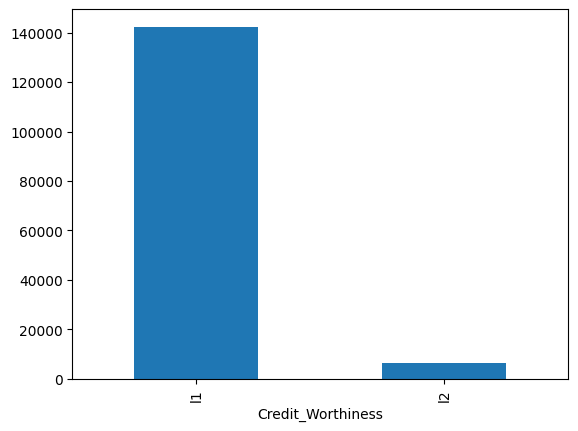

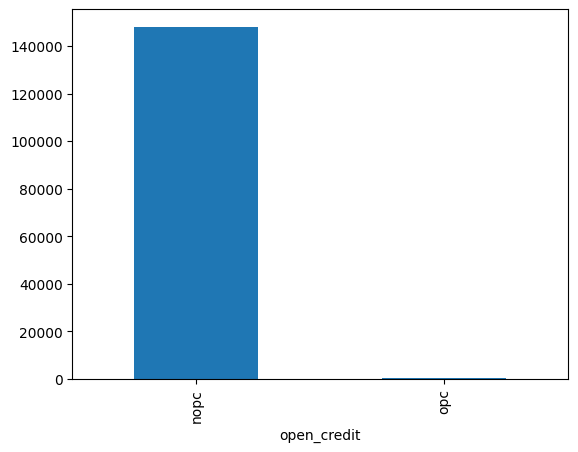

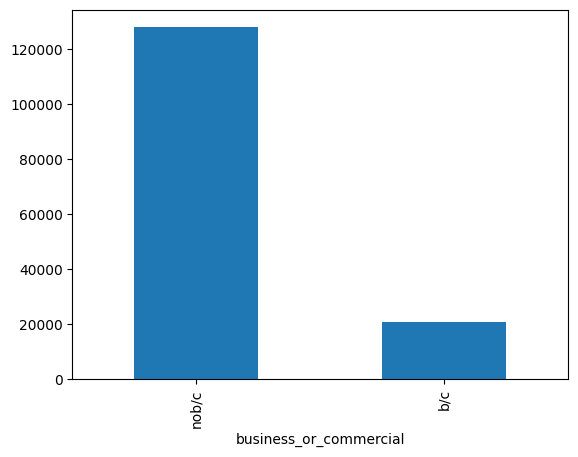

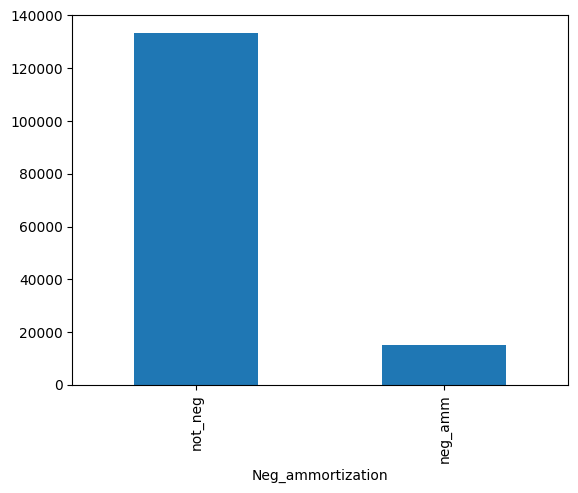

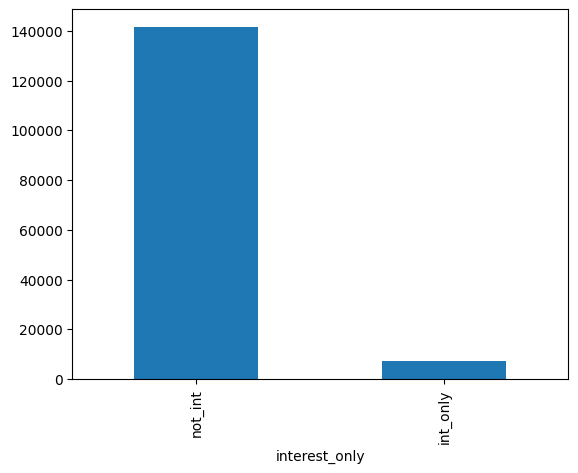

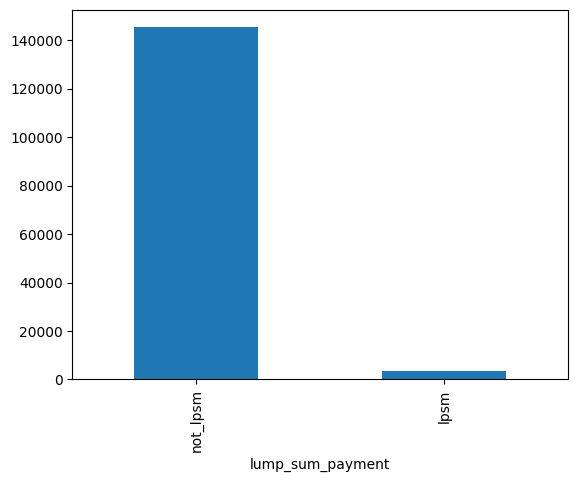

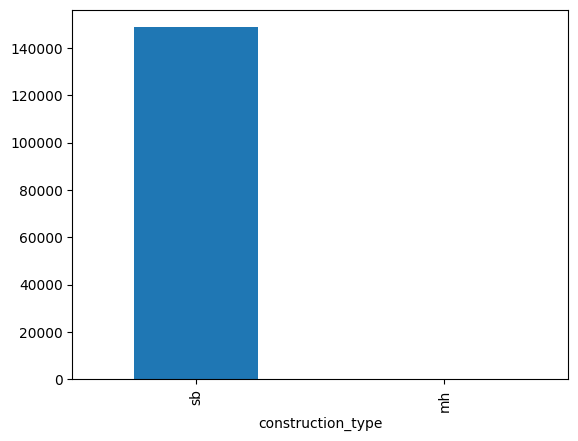

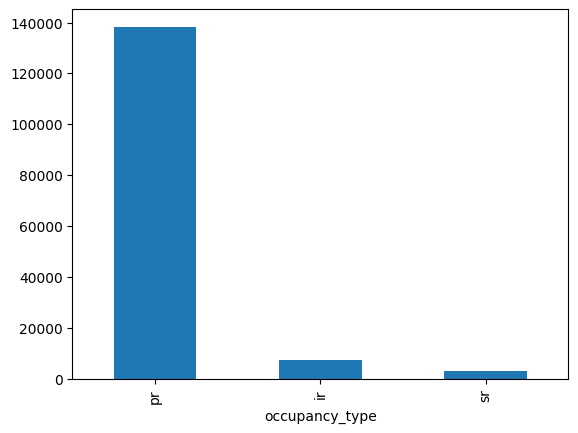

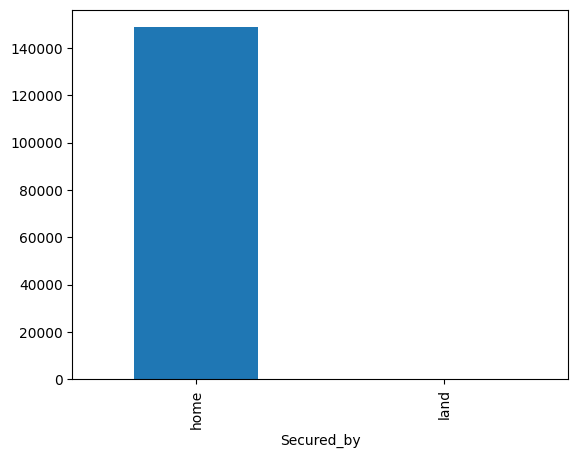

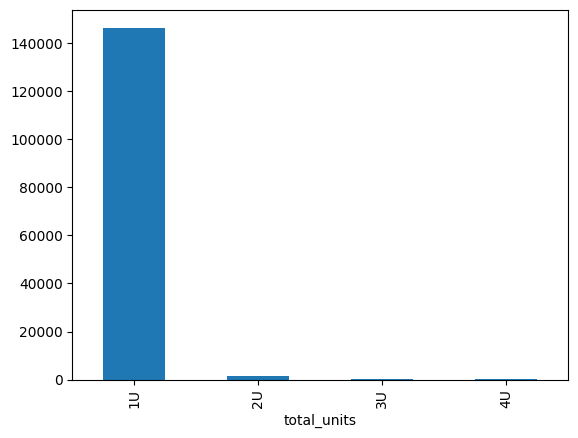

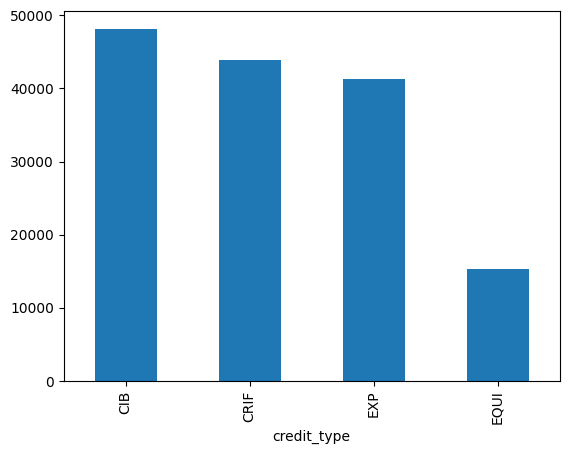

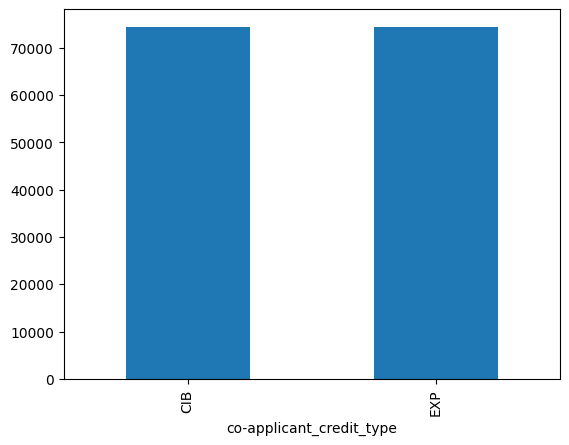

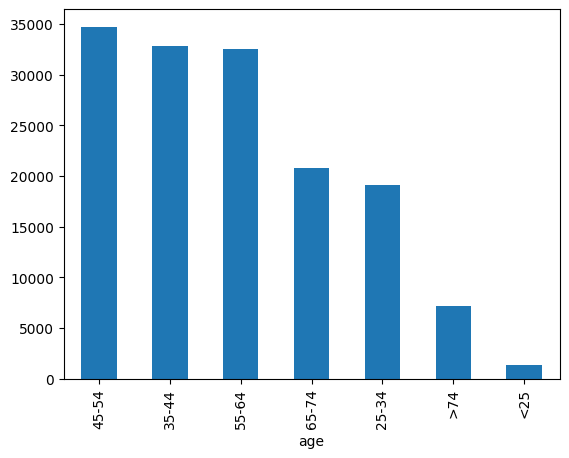

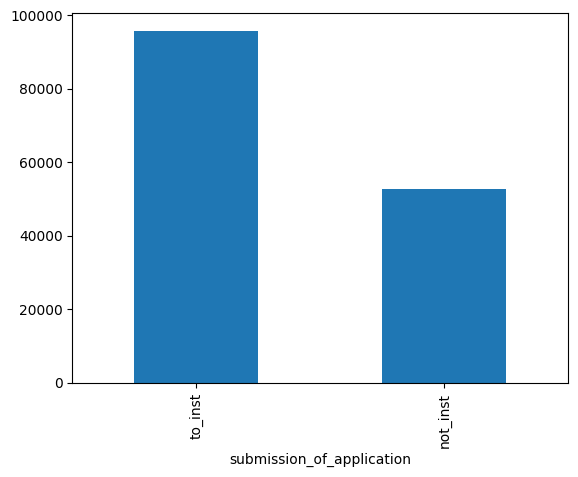

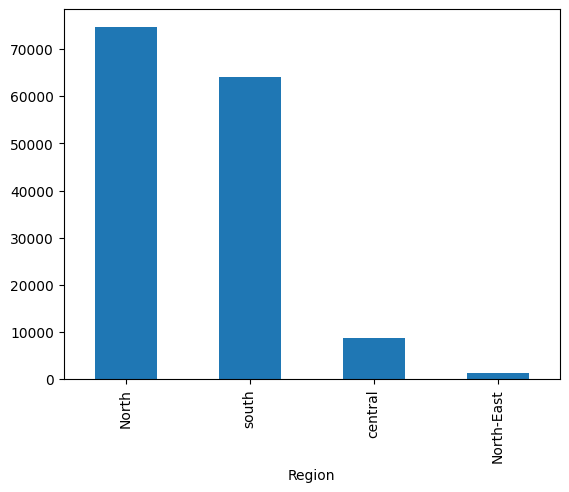

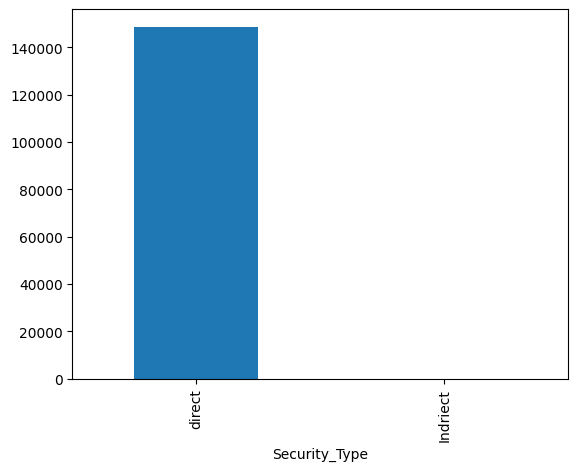

In [43]:
for column in loan_df.select_dtypes("object").columns:
    loan_df[column].value_counts(normalize=False).plot.bar()
    plt.show()

In [44]:
(loan_df[["Credit_Score", "loan_amount"]]
 - loan_df[["Credit_Score", "loan_amount"]].mean()) / loan_df[["Credit_Score", "loan_amount"]].std()

,Credit_Score,loan_amount
0,0.502356,-1.166976
1,-1.275409,-0.677604
2,1.158230,0.409888
3,-0.973362,0.681761
4,-0.843913,1.986752
...,...,...
148665,-0.352007,0.573012
148666,-1.128700,1.388631
148667,0.019080,0.627387
148668,0.321127,-0.731979


In [45]:
from sklearn.preprocessing import StandardScaler
 
std = StandardScaler()
 
std.fit_transform(loan_df[["Credit_Score", "loan_amount"]])

array([[ 0.50235739, -1.16697989],
       [-1.27541323, -0.6776066 ],
       [ 1.15823392,  0.40988958],
       ...,
       [ 0.01907994,  0.62738881],
       [ 0.32112834, -0.73198141],
       [ 1.12371411,  0.40988958]], shape=(148670, 2))

In [46]:
loan_df["total_units"].value_counts()

total_units
1U    146480
2U      1477
3U       393
4U       320
Name: count, dtype: int64

In [47]:
loan_df = loan_df.assign(
    total_units = loan_df["total_units"].map({
        "1U": "1U",
        "2U": "2U+",
        "3U": "2U+",
        "4U": "2U+"}),
    loan_amt_v_income = loan_df["loan_amount"]/loan_df["income"]
)
 
loan_df[["total_units", "loan_amt_v_income"]].head()

,total_units,loan_amt_v_income
0,1U,66.954023
1,1U,41.465863
2,1U,42.879747
3,1U,38.425926
4,1U,66.714559


<Axes: xlabel='loan_amt_v_income', ylabel='Count'>

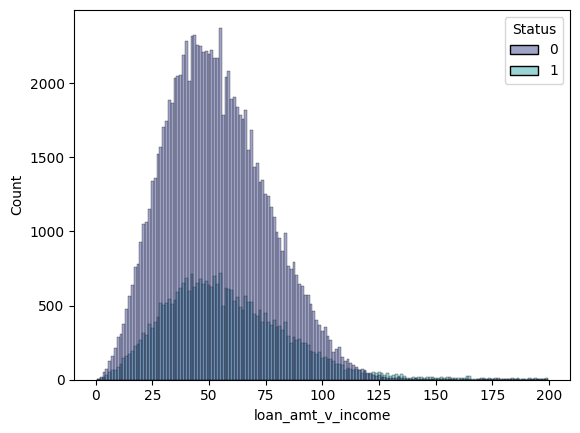

In [53]:
sns.histplot(
    loan_df.query("loan_amt_v_income < 200"),
    hue="Status",
    x="loan_amt_v_income",
    palette="mako"
)

In [54]:
def add_deviation_feature(X, feature, category):
   
    # temp groupby object
    category_gb = X.groupby(category)[feature]
   
    # create columns of category means and standard deviations
    category_mean = category_gb.transform(lambda x: x.mean())
    category_std = category_gb.transform(lambda x: x.std())
   
    # compute stds from category mean for each feature value,
    # add to X as new feature
    deviation_feature = (X[feature] - category_mean) / category_std
    X[feature + '_Dev_' + category] = deviation_feature
 
 
add_deviation_feature(loan_df, 'income', 'Region')
 
loan_df[["income", "Region", "income_Dev_Region"]].sample(20).sort_values("income")

,income,Region,income_Dev_Region
32932,1080.0,central,-1.122100
31298,1800.0,North,-0.774064
139800,3120.0,North,-0.577104
54176,3120.0,North,-0.577104
2730,3300.0,south,-0.571869
52538,3720.0,south,-0.507035
124457,5220.0,North,-0.263758
49113,5400.0,central,-0.229418
66676,5520.0,North,-0.218994
109908,5580.0,south,-0.219911


In [55]:
# Drop useless/unpromising columns
 
prep_loan_df = loan_df.drop([
    "year",
     "ID",
     "open_credit",
    "construction_type",
    "Security_Type",
    "Secured_by"],
    axis=1
)
 
prep_loan_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 30 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   loan_limit                 145326 non-null  str    
 1   Gender                     148670 non-null  str    
 2   approv_in_adv              147762 non-null  str    
 3   loan_type                  148670 non-null  str    
 4   loan_purpose               148536 non-null  str    
 5   Credit_Worthiness          148670 non-null  str    
 6   business_or_commercial     148670 non-null  str    
 7   loan_amount                148670 non-null  int64  
 8   rate_of_interest           112231 non-null  float64
 9   Interest_rate_spread       112031 non-null  float64
 10  Upfront_charges            109028 non-null  float64
 11  term                       148629 non-null  float64
 12  Neg_ammortization          148549 non-null  str    
 13  interest_only              148670 non-nu

In [56]:
# data splitting
 
from sklearn.model_selection import train_test_split
 
X = pd.get_dummies(prep_loan_df[["loan_limit", "Gender", "loan_amount"]], drop_first=True)
y = prep_loan_df["Status"]
 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=2023)
 
print(f"Training Size: {X_train.shape[0]}, Test Size: {X_test.shape[0]}")

Training Size: 118936, Test Size: 29734


In [57]:
# feature scaling
 
from sklearn.preprocessing import StandardScaler
 
std = StandardScaler()
 
X_train_std = std.fit_transform(X_train)
X_test_std = std.transform(X_test)
 

In [58]:
loan_df["income"] = loan_df["income"].fillna(loan_df["income"].mean())
loan_df["loan_amount"] = loan_df["loan_amount"].fillna(loan_df["loan_amount"].mean())
 
loan_df
 

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1,loan_amt_v_income,income_Dev_Region
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,CIB,25-34,to_inst,98.728814,south,direct,1,45.0,66.954023,-0.812683
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EXP,55-64,to_inst,NaN,North,direct,1,NaN,41.465863,-0.299569
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,CIB,35-44,to_inst,80.019685,south,direct,0,46.0,42.879747,0.382123
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,CIB,45-54,not_inst,69.376900,North,direct,0,42.0,38.425926,0.729996
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,EXP,25-34,not_inst,91.886544,North,direct,0,39.0,66.714559,0.515130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148665,173555,2019,cf,Sex Not Available,nopre,type1,p3,l1,nopc,nob/c,...,EXP,55-64,to_inst,71.792763,south,direct,0,48.0,55.534351,0.132047
148666,173556,2019,cf,Male,nopre,type1,p1,l1,nopc,nob/c,...,CIB,25-34,not_inst,74.428934,south,direct,0,15.0,82.142857,0.020903
148667,173557,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,45-54,not_inst,61.332418,North,direct,0,49.0,64.710145,-0.013081
148668,173558,2019,cf,Female,nopre,type1,p4,l1,nopc,nob/c,...,EXP,55-64,to_inst,70.683453,North,direct,0,29.0,27.521008,0.022730


In [59]:
loan_df
 
loan_df["loan_amt_v_income"] = (
    loan_df["loan_amt_v_income"]
    .fillna(loan_df["loan_amt_v_income"].mean())
    .replace([np.inf, -np.inf], loan_df["loan_amt_v_income"].median())
)
 
loan_df.describe()

,ID,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1,loan_amt_v_income,income_Dev_Region
count,148670.000000,148670.0,1.486700e+05,112231.000000,112031.000000,109028.000000,148629.000000,1.335720e+05,148670.000000,148670.000000,133572.000000,148670.000000,124549.000000,148670.000000,1.395200e+05
mean,99224.500000,2019.0,3.311177e+05,4.045476,0.441656,3224.996127,335.136582,4.978935e+05,6957.338876,699.789103,72.746457,0.246445,37.732932,56.262544,5.683527e-17
std,42917.476598,0.0,1.839093e+05,0.561391,0.513043,3251.121510,58.409084,3.599353e+05,6293.492004,115.875857,39.967603,0.430942,10.545435,92.089246,9.999892e-01
min,24890.000000,2019.0,1.650000e+04,0.000000,-3.638000,0.000000,96.000000,8.000000e+03,0.000000,500.000000,0.967478,0.000000,5.000000,0.599257,-1.413086e+00
25%,62057.250000,2019.0,1.965000e+05,3.625000,0.076000,581.490000,360.000000,2.680000e+05,3840.000000,599.000000,60.474860,0.000000,31.000000,38.417191,-4.977726e-01
50%,99224.500000,2019.0,2.965000e+05,3.990000,0.390400,2596.450000,360.000000,4.180000e+05,6000.000000,699.000000,75.135870,0.000000,39.000000,52.555556,-1.921246e-01
75%,136391.750000,2019.0,4.365000e+05,4.375000,0.775400,4812.500000,360.000000,6.280000e+05,8280.000000,800.000000,86.184211,0.000000,45.000000,68.269231,2.431922e-01
max,173559.000000,2019.0,3.576500e+06,8.000000,3.357000,60000.000000,360.000000,1.650800e+07,578580.000000,900.000000,7831.250000,1.000000,61.000000,25275.000000,8.823276e+01


In [64]:
from sklearn.model_selection import train_test_split

X = pd.get_dummies(prep_loan_df[["loan_amount", "income", "Gender", "loan_amt_v_income"]], drop_first=True)
y = prep_loan_df["Status"]
X = X.astype(float) 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=2023)

print(f"Training Size: {X_train.shape[0]}, Test Size: {X_test.shape[0]}")

Training Size: 118936, Test Size: 29734


In [65]:
from sklearn.preprocessing import StandardScaler
 
std = StandardScaler()
 
X_train_std = std.fit_transform(X_train)
X_test_std = std.transform(X_test)

ValueError: Input X contains infinity or a value too large for dtype('float64').

In [66]:
from sklearn.neighbors import KNeighborsClassifier
 
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_std, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [67]:
knn.score(X_train_std, y_train)  #accuracy
 
knn.score(X_test_std, y_test)  #accuracy
 

0.7050514562453757